# DS202W Spring Term Summative
**Candidate Number:** 74280

---

In [1]:
# === ALL IMPORTS ===
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from adjustText import adjust_text
import missingno as msno
from IPython.display import Markdown, display


# NLP / Text
import spacy
# spaCy model downloaded with %%capture to suppress output
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], capture_output=True)
import gensim
from gensim import corpora
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import networkx as nx

# Dimensionality Reduction
from sklearn.decomposition import PCA
from umap import UMAP

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from hdbscan import HDBSCAN

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Topic Modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Evaluation
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# Misc
from collections import Counter
from tqdm import tqdm
import random
from matplotlib.patches import Patch


## 1. Dataset Choice

After considering the goals of part a and part b, and briefly exploring each dataset, I decided to work with the petitions data. This project is mainly about working with textual data, and comes in two parts where using the same dataset for each adds the boon of continued analysis. The petitions data is text-rich, and has very long pieces of text data for some columns. The glassdoor dataset has short and formulaic text, which would force us to use embeddings over TF-IDF and hurt our ability to extract meaningful information. The chicago dataset has longer text but lots of text missingness, which would introduce distributional and demographic biases that I would prefer not to work with. Documents in petitions will carry more signal, and give performance improvements to models we select, and open up modelling decisions that might have been restricted by lack of signal in text data. The petitions data also has a floor of some text per row. Petitions also has an interesting subject matter which will make choosing a research question easier.

## 2. Data Loading & Reproducibility

You can find information on where to download the data in the README. Data should live in the repo root and be named `uk_petitions_final.csv`. The code below loads from that relative path.

In [2]:
df = pd.read_csv("uk_petitions_final.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (11662, 20)


,petition_id,action,background,additional_details,state,signature_count,created_at,updated_at,rejected_at,opened_at,closed_at,government_response_at,debate_threshold_reached_at,scheduled_debate_date,debated,debate_overview,government_response_summary,government_response_body,rejection_code,rejection_details
0,700001,Fund reconstruction surgery and psychosexual t...,We urge the Government to support FGM survivor...,I know firsthand the physical and emotional ch...,closed,939,2024-10-30T14:20:17.653Z,2025-04-30T23:00:02.678Z,NaN,2024-10-31T17:30:30.989Z,2025-04-30T22:59:59.999Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,700005,Apply for the UK to join the European Union as...,I believe joining the EU would boost the econo...,I think the Single Market would bring inward i...,closed,136650,2024-10-30T14:28:44.914Z,2025-09-17T17:13:14.611Z,NaN,2024-10-31T17:46:29.187Z,2025-04-30T22:59:59.999Z,2024-11-19T14:28:18.247Z,2025-02-11T17:25:10.000Z,2025-03-24,NaN,NaN,The Government was elected on a manifesto that...,Since taking office this Government has been w...,NaN,NaN
2,700006,Rejoin the European Union,The UK Government should seek to rejoin the Eu...,The real black hole in the UK’s economy is all...,rejected,10,2024-10-30T14:32:33.904Z,2024-10-31T17:49:06.668Z,2024-10-31T17:48:58.550Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,duplicate,You may wish to sign this petition which calls...
3,700007,Require dating apps to ensure ID and DBS check...,I believe to better protect the public from of...,I believe that the ability for violent offende...,closed,1216,2024-10-30T14:34:44.936Z,2025-06-27T07:02:55.390Z,NaN,2024-11-05T18:42:41.810Z,2025-05-05T22:59:59.999Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,700009,"Fund Covid booster vaccines for all, with prio...",Long Covid can ruin lives and cause financial ...,"Currently, many Long Covid sufferers are unabl...",closed,716,2024-10-30T14:53:44.200Z,2025-06-05T23:00:05.025Z,NaN,2024-12-05T10:04:57.429Z,2025-06-05T22:59:59.999Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Profiling

In [3]:
# Shape already printed in data loading cell above

In [4]:
# Column types
df.dtypes

petition_id                      int64
action                             str
background                         str
additional_details                 str
state                              str
signature_count                  int64
created_at                         str
updated_at                         str
rejected_at                        str
opened_at                          str
closed_at                          str
government_response_at             str
debate_threshold_reached_at        str
scheduled_debate_date              str
debated                        float64
debate_overview                    str
government_response_summary        str
government_response_body           str
rejection_code                     str
rejection_details                  str
dtype: object

The document columns are `action`, `background`, `additional_details`, `debate_overview`, `goverment_response_summary`, `government_response_body`, and `rejection_details`. Some columns like `state`, `debated`, and `rejection_code` are all categorical. 

In [5]:
# Missingness
df.isnull().sum().sort_values(ascending=False)

debated                        11662
debate_overview                11661
scheduled_debate_date          11612
debate_threshold_reached_at    11596
government_response_body       11391
government_response_summary    11391
government_response_at         11391
closed_at                       8423
opened_at                       6441
rejection_details               5398
rejected_at                     5220
rejection_code                  5220
additional_details               570
action                             0
updated_at                         0
created_at                         0
signature_count                    0
state                              0
background                         0
petition_id                        0
dtype: int64

Every petition has action and background documents. Almost all of them have additional details, worth investigating why only some don't. Only a small percentage are actually debated, and all but one debate had a debate overview. Strangely, there are more petitions with opened at vals than closed at vals. I'm not sure if that will matter in part a but it might matter in part b.

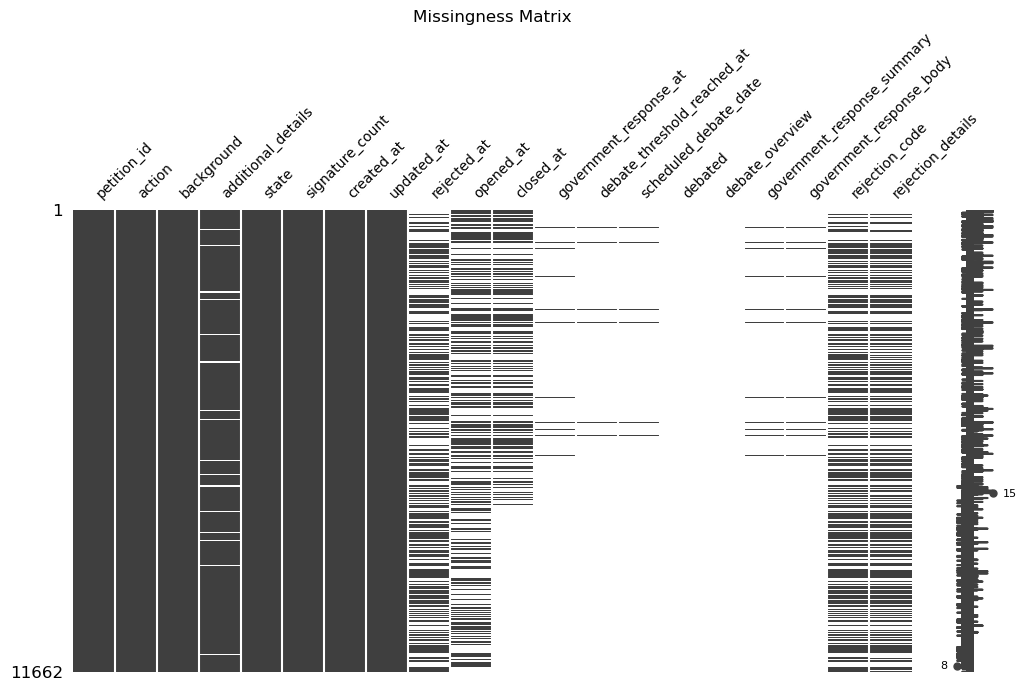

In [6]:
# Systematic Missingness
msno.matrix(df, figsize=(12, 6), fontsize=10)
plt.title("Missingness Matrix")
plt.show()

Missingness in additional details does not immediately appear systematic. Same with rejected at, opened at, but closed off has a cutoff. It appears that all cases are either rejected or opened. Lets check that, but first inspect to see if additional details is systematic missing. 

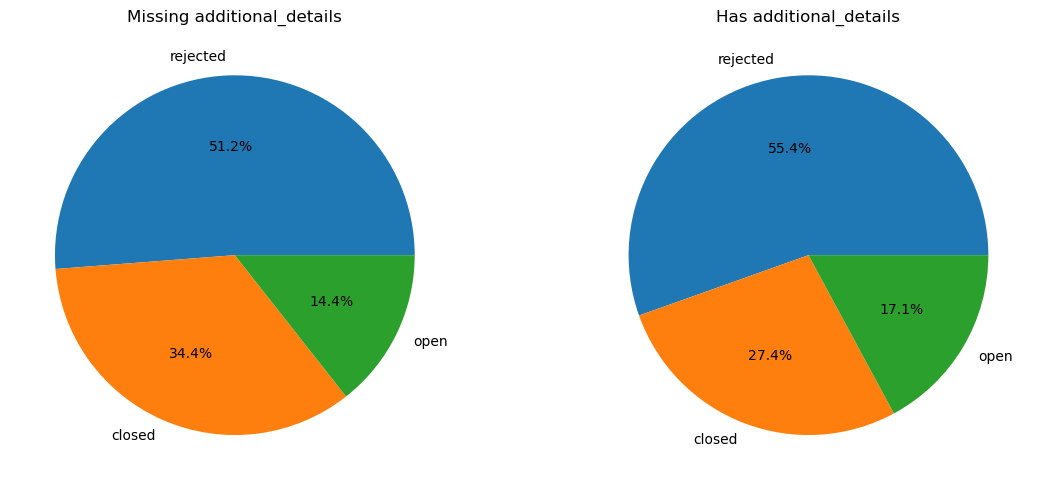

In [7]:
# Check proportion of state in missing and not missing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

missing = df[df['additional_details'].isnull()]['state'].value_counts()
not_missing = df[df['additional_details'].notna()]['state'].value_counts()

axes[0].pie(missing, labels=missing.index, autopct='%1.1f%%')
axes[0].set_title('Missing additional_details')

axes[1].pie(not_missing, labels=not_missing.index, autopct='%1.1f%%')
axes[1].set_title('Has additional_details')

plt.tight_layout()
plt.show()

Proportions across both charts indicate that missing additional details are not systematically related to state.

In [8]:
# Check missing additional details by signature count
df.groupby(df['additional_details'].isnull())['signature_count'].describe()

,count,mean,std,min,25%,50%,75%,max
additional_details,,,,,,,,
False,11092.0,1873.983502,32162.925382,4.0,7.0,21.0,79.0,2984192.0
True,570.0,8491.029825,136906.590847,6.0,8.0,21.0,92.0,3084715.0


Both have similar IQR marks, so I'm satisfied that there isn't discrimination based off of signature count. 

In [9]:
df['opened_at'].count() + df['rejected_at'].count()

11663

Total number of rows is 11662, so there is one row that occupies both, but I am going to count my suspicion as confirmed. The gap between opened_at and closed_at counts is because some petitions are still open and haven't closed yet.

In [10]:
# Distribution of petition states
df["state"].value_counts()

state
rejected    6442
closed      3239
open        1981
Name: count, dtype: int64

This gives us an even better picture. Petitions are either rejected, closed, or open.

In [11]:
# Text length distributions
text_cols = ["action", "background", "additional_details", "government_response_body", "rejection_details"]
for col in text_cols:
    non_null = df[col].dropna()
    print(f"{col}: {len(non_null)} non-null, mean length {non_null.str.len().mean():.0f} chars")

action: 11662 non-null, mean length 63 chars
background: 11662 non-null, mean length 216 chars
additional_details: 11092 non-null, mean length 365 chars
government_response_body: 271 non-null, mean length 3124 chars
rejection_details: 6264 non-null, mean length 260 chars


Actions are short statements, backgrounds and rejection details are concise paragraphs, additional details are regular paragraphs, but government responses are long, very long. Greater than an essay each. 

## 4. Exploratory Data Analysis

I want to start EDA by looking at a sample of our text documents. 

In [12]:
# Look at sample of lower-char documents
text_cols = ["action", "background", "additional_details", "rejection_details"]
md_lines = ["# EDA: Sample Petitions by State\n"]

# Sample stratified by state
for state in df["state"].unique():
    subset = df[df["state"] == state]

    # One q25 and q75 per state in the sample
    q25 = subset["signature_count"].quantile(0.25)
    q75 = subset["signature_count"].quantile(0.75)

    bottom = subset[subset["signature_count"] <= q25].sample(1, random_state=42)
    top = subset[subset["signature_count"] >= q75].sample(1, random_state=42)

    md_lines.append(f"## State: {state}\n")

    for label, row_df in [("Bottom Quartile", bottom), ("Top Quartile", top)]:
        row = row_df.iloc[0]
        md_lines.append(f"### {label} (Signatures: {int(row['signature_count']):,})\n")
        for col in text_cols:
            val = row.get(col, np.nan)
            content = str(val).strip() if pd.notna(val) else "N/A"
            md_lines.append(f"**{col}:**\n\n{content}\n")
        md_lines.append("---\n")

with open("sample_petitions.md", "w") as f:
    f.write("\n".join(md_lines))

display(Markdown("\n".join(md_lines)))

# EDA: Sample Petitions by State

## State: closed

### Bottom Quartile (Signatures: 35)

**action:**

Abolish Vehicle Excise Duty and add the cost to Fuel Duty

**background:**

I would like Vehicle Excise Duty (VED) to be completely abolished. Instead, add the cost to Fuel Duty. I think this will mean that for more fuel-efficient vehicles which generally use less fuel and emit less CO2, drivers will pay less for fuel, and this change may help wider zero carbon policies.

**additional_details:**

Older, less efficient vehicles can disappear naturally without some families potentially feeling forced into rash decisions about vehicle use.
 
In my view, any attempt to fast-track carbon reduction by hiking certain taxes like VED may make the country poorer. I think the infrastructure needed to do the things government wants to do is decades behind. I believe that it should be the case that the more fuel you use, the more tax you pay.

**rejection_details:**

N/A

---

### Top Quartile (Signatures: 1,657)

**action:**

Stop publicly funded legal aid to illegal immigrants

**background:**

We think that the government should stop publicly funded legal aid for illegal immigrants to fight their deportation.

**additional_details:**

N/A

**rejection_details:**

N/A

---

## State: rejected

### Bottom Quartile (Signatures: 6)

**action:**

Reform PMQs:Ban Misleading Claims,Ensure Answers,Enforce Speaker Accountability

**background:**

Reform PMQs as follows: Prohibition of Misleading Claims:An example being the "£22B Black Hole" claims, which are misleading. Mandatory Response to Questions: ensure PM answers questions. Speaker’s Role in Upholding Standards: enforce Speaker to acknowledge unanswered questions for accountability

**additional_details:**

The "£22B Black Hole" is debunked by fiscal experts including reports from the Office for Budget Responsibility, yet its use misleads the House, undermine public trust and the integrity of parliament

The Prime Minister must be held accountable for directly addressing questions posed during PMQs, evasion is weakening scrutiny

The Speaker must uphold accountability by noting unanswered questions

These reforms are urgent to restore trust in PMQs, ensuring transparency and democratic integrity

**rejection_details:**

We can't accept your petition because the UK Government and Parliament as a whole aren't responsible for the issue you raise. Order in the Commons is the responsibility of the Speaker personally, and the Prime Minister is responsible for answers to questions.

---

### Top Quartile (Signatures: 14)

**action:**

Improve resilience and safety of the M4 PoW Bridge and the M48 Severn Bridge

**background:**

Conduct a full review of the 9 December 2025 disruption, upgrade safety-critical infrastructure on both Severn bridges, strengthen wind-resilience, improve public communication, and publish a long-term strategy ensuring at least one crossing remains reliably open.

**additional_details:**

The simultaneous M4 and M48 closures exposed a major weakness in cross-Severn travel. These bridges are vital, and full shutdowns disrupt commuters, businesses and emergency services. We need an independent review to improve maintenance, weather-closure protocols, contingency planning, and to invest in reliable alternative routes. Stronger infrastructure and clearer communication are essential to prevent future total closures and protect the region’s connectivity.

**rejection_details:**

We can’t accept petitions that call for action at a local level.

You could ask your MP to take action on your concerns about this issue, including by asking them to present a public (paper) petition about this.

You can find contact details for your local MP here: https://members.parliament.uk/FindYourMP

And you can find out how to ask your MP to present a public (paper) petition here: https://www.parliament.uk/get-involved/sign-a-petition/paper-petitions/

You could also raise your issue with a local councillor who represents you. You can use this page to find out who your local councillors are, and how to contact them: https://www.gov.uk/find-your-local-councillors

---

## State: open

### Bottom Quartile (Signatures: 25)

**action:**

UC must cover housing costs following marriage breakdown in forces accommodation

**background:**

Following marriage breakdown in families living in in forces accommodation, the party occupying the property while seeking alternative accommodation can be classed as a 'trespasser', and may therefore be ineligible for support with housing costs through Universal Credit.

**additional_details:**

This can make it incredibly difficult for spouses going through a marriage separation. The word 'Trespass' means Universal Credit will often not help with the housing element of Universal Credit, so the spouse is eligible for the full cost. The spouse is given a breakdown of this cost for example water, council tax, garage rent, house rent and are expected to pay this rent and charges. This can leave families in financial difficulty, in debt when already struggling.

**rejection_details:**

N/A

---

### Top Quartile (Signatures: 623)

**action:**

Reduce VAT on hospitality to 10%: protect jobs, communities & UK competitiveness

**background:**

Reduce VAT on hospitality to 10% to prevent closures & protect tax revenue. When venues close, HMRC loses 100% of its VAT, business rates, PAYE & corporation tax, reducing employment & supply chains. We believe a lower VAT rate would keep viable businesses trading, securing jobs & ongoing revenue.

**additional_details:**

Hospitality businesses operate on very tight margins and struggle to absorb 20% VAT alongside rising food, energy, wage and rent costs. We believe a permanent reduction to 10% VAT would save jobs, keep venues open, support apprenticeships and skills, and strengthen high streets – it would help businesses survive and continue contributing billions to the UK economy.
 
This would protect local jobs, keep pubs and restaurants open, and help high streets, tourism and communities survive.

**rejection_details:**

N/A

---


This is interesting. First, I notice that signature count most likely has a correlation with acceptance. This could come from two angles; low sig counts could lead to rejection, or non-rejected petitions could gain more time to amass more sigs. I should be careful to draw causal relationships here.

About the text itself, I can already see that phrasing like "I think" vs "We think" may have an impact on acceptance. Another thing worth noting is how additional details don't make a lot of sense without background. Action provides a bit of a summary of the two and also poses the problem to be addressed. This could be relevant later in similarities. 

Background contains the benefit more often than not expresses the benefit of the action and why the proposers think so. The additional details gives context for why the issue is important. Including bigrams may alsobe useful. terms like illegal-immigrants have a very specific signal as opposed to illegal and immigrants seperately. These documents focus around the issue and the benefit, which can probably both be neatly identified by the keywords in action and the keywords in background and additional details. 

Because action seems to focus on the issue and background tends to focus on the benefit to be had, it could be possible to discern both based off of a bag-of-words based approach. 

Additional details seems like a summary of background and action, rephrasing similar points but with more illustration, like 'keep veues open' or 'for example water, council tax, garage rent...'; additional details is painting a picture where the other column documents are more to the point about the problem, the solution, and the benefit. 

The rejection details gave two different reasons but both represented a similar cause for rejection; the petitions were out of scope. This exposes one of what could be many rejection classes, where some are rejected on principle that they are out of scope, and others that are in scope are rejected for more nuanced reasons. 



In [13]:
# Select government response with median length
gov_responses = df[df["government_response_body"].notna()].copy()
gov_responses["gov_len"] = gov_responses["government_response_body"].str.len()
median_len = gov_responses["gov_len"].median()
median_row = gov_responses.iloc[(gov_responses["gov_len"] - median_len).abs().argsort()[:1]].iloc[0]

text = median_row["government_response_body"]
n = len(text)

md_lines = [
    "# EDA: Government Response Sample (Median Length)\n",
    f"**Petition action:** {median_row['action']}\n",
    f"**Signatures:** {int(median_row['signature_count']):,}\n",
    f"**Total length:** {n:,} chars\n",
    "---\n",
    "## First ~500 chars\n",
    f"{text[:500]}\n",
    "---\n",
    "## Middle ~500 chars\n",
    f"{text[n//2 - 250 : n//2 + 250]}\n",
    "---\n",
    "## Last ~500 chars\n",
    f"{text[-500:]}\n",
]

display(Markdown("\n".join(md_lines)))

# EDA: Government Response Sample (Median Length)

**Petition action:** Fund more staff training and better facilities in psychiatric hospitals

**Signatures:** 10,400

**Total length:** 3,062 chars

---

## First ~500 chars

The Government has confirmed that we will fulfil our commitment to recruit an additional 8,500 mental health workers for children and adults to ease pressure on busy mental health services by the end of the Parliament. We are more than halfway towards our target.  We will also publish a 10 Year Workforce Plan to create a workforce ready to deliver a transformed service. They will be more empowered, more flexible and more fulfilled. This will ensure the NHS has the right people in the right place

---

## Middle ~500 chars

ed to improving mental health accommodation. The NHS has invested £615 million to replace mental health dormitories with private rooms, following recommendations in the Independent Review of the Mental Health Act.  In addition, we have allocated £750 million over 2025-26 to address high-priority safety issues in NHS estates, including within mental health settings.  The 10 Year Health Plan sets out our vision for the neighbourhood health service. As part of this, we will transform the current me

---

## Last ~500 chars

anced rights and support, and ensure everyone is treated with dignity and respect throughout treatment.  NHS England’s mental health, learning disability and autism inpatient quality transformation programme will support cultural change and a new model of care for the future across all NHS-funded mental health inpatient settings. Local health systems have now published their 3-year plans for localising and realigning inpatient care in line with this vision.  Department of Health and Social Care 


These documents are very long, but on a text level appear to address the petitions in a structured way. They state an approach to the problem presented, walk though methodology and specifics, and then conclude with goals and how action is being taken. The fact that these contain a lot of reiteration of context and keywords, + the fact that there are far less government responses than useable datapoints makes me lean towards not using this column. 

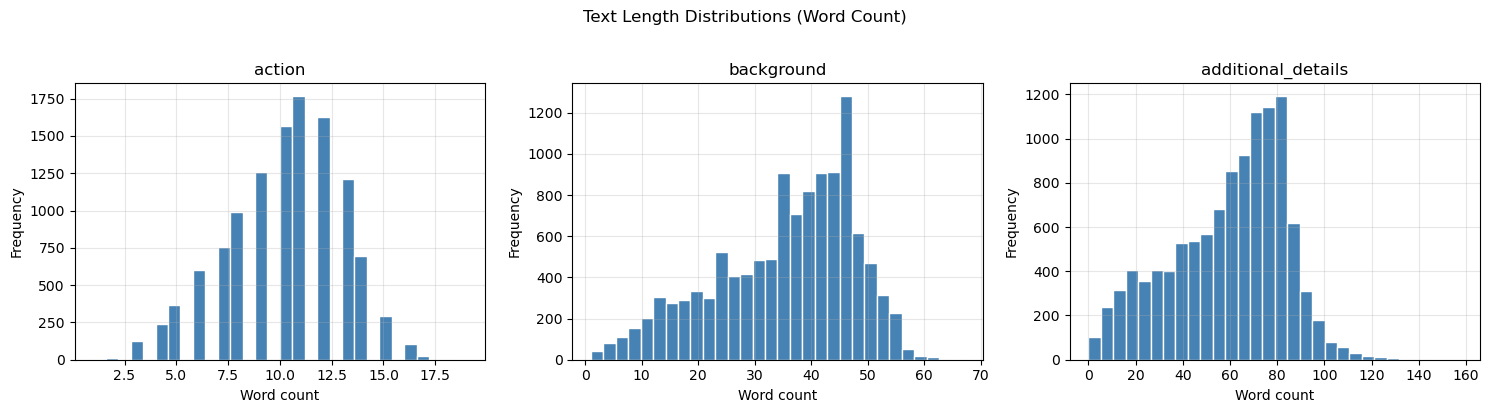

In [14]:
# Text length distributions (word count) for action, background, additional_details
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ["action", "background", "additional_details"]
 
for ax, col in zip(axes, cols):
    word_counts = df[col].dropna().str.split().str.len()
    ax.hist(word_counts, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)
 
fig.suptitle("Text Length Distributions (Word Count)", y=1.02)
plt.tight_layout()
plt.show()

Length is fairly normally distributed for actions, but background and additional details are heavily right skewed, with strong dropoffs at 50 and 80 words repectively. This could be because of an internally recommended length for both of these sections. Low values in background and additional details are not separated from their distributions, and don't necessarily appear to be outliers. Values on the high end are few and far between, suggesting that they are outliers. 

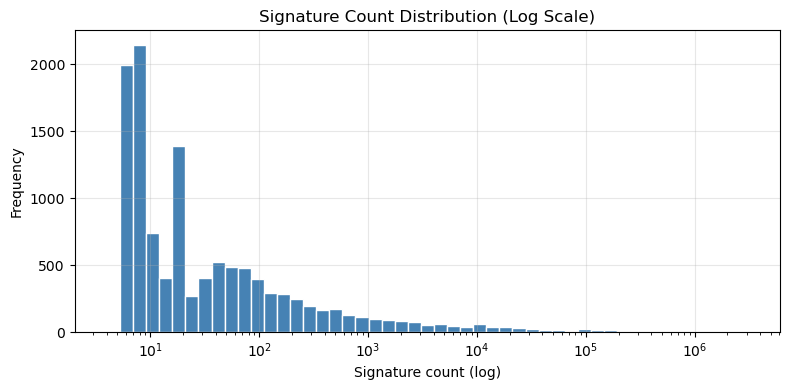

In [15]:
# Signature count distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["signature_count"], bins=np.logspace(np.log10(df["signature_count"].min()), np.log10(df["signature_count"].max()), 50), color="steelblue", edgecolor="white")
ax.set_xscale("log")
ax.set_title("Signature Count Distribution (Log Scale)")
ax.set_xlabel("Signature count (log)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Log scaled sig count is heavily right skewed. The peak around 10-15 signatures is interesting, perhaps there is some minimum that guidelines recommend clearing. Regardless, there are many petitions with less than 10 signatures, and a smooth enough decline after. There do appear to be outliers on the right of the distribution. The 10,000 and 100,000 signature thresholds that trigger government responses and parliamentary debate consideration sit far into the right tail, meaning very few petitions reach those levels.

I'm leaning towards using just action, background, and additional details. Debate overview and government response inlcude interesting text data but are too sparse in our dataset for how I want to compare similarity and anomaly.

## 5. Subsampling

I'm working on a 2022 Mac Air M2 chip with 16gb ram, so 12k rows doesn't really call for subsampling. The heaviest thing I might run on this dataset is BERTopic because of the embedding + UMAP + HDBSCAN, but that still wouldn't take more than 15 mins max. I'll work with the whole set.

## 6. Text Preprocessing

After exploring each text column during EDA, I chose to concatenate action, background, and additional_details into a single document per petition. Each column serves a distinct role: action states the problem and proposed solution, background argues the benefit, and additional_details illustrates and elaborates on the same points. While these roles differ, those distinctions are based on a small sample and remain assumptions. Concatenating extends document length from roughly 50 words to around 115 on average, strengthening signal for text representation methods like TF-IDF and embedding models that benefit from more context per document. This tradeoff favors signal strength over interpretability based on assumptions.

The 570 petitions missing additional_details are dropped. Missingness was checked against petition state and signature count during profiling and found not to be systematic. Losing fewer than 5% of rows is a reasonable tradeoff for the boost in document length and consistency across the corpus.
government_response_body, rejection_details, and debate_overview are excluded. Government responses and debate overviews only exist for small, inherently biased subsets, and debate overview contains only a single non-null entry. Rejection details exist only for rejected petitions. Using any of these would restrict analysis to a non-representative subsample.

In [16]:
df = df.dropna(subset=['additional_details'])
df['petition_concat'] = df['action'] + ' ' + df['background'] + ' ' + df['additional_details']

I am going to use spaCy's `en_core_web_sm` to preprocess my data. The large version uses its own vectorization method, but I want to preserve choice of vectorization method for later. I might want TF-IDF for Part A and then sentence-transformers for Part B, or some other combo. For now, I just want to tokenize, lemmatize, and handle stopwords.

spaCy processes the text in one pass and labels each token with attributes like whether it's a stopword, punctuation, a number, etc. I then filter based on those labels. Specifically, I remove default spaCy stopwords, punctuation, and numbers. I also drop any single-character tokens, since meaningful single characters like "I" are already caught by stopword removal, and anything else at that length is noise. Tokens of length two and above are kept because abbreviations like "UK", "EU", and "AI" carry real signal in petition text. Lemmatization handles lowercasing implicitly since spaCy lemmas are lowercase.

I save two versions of the cleaned text: one with stopwords removed for methods like TF-IDF that benefit from it, and one with stopwords kept for any downstream method that works better on more natural-sounding input. The raw concatenated text in `petition_concat` is also preserved for methods like BERTopic that handle their own tokenization and embedding internally.

Domain-specific stopwords like "government" or "petition" are not removed at this stage. I want to see post-preprocessing frequency data before making that call, rather than guessing upfront about what's too common to be useful.

In [17]:
nlp = spacy.load('en_core_web_sm')

def preprocess(doc, remove_stopwords=True):
    tokens = []
    for token in doc:
        if token.is_punct:
            continue
        if token.like_num:
            continue
        if len(token.text) < 2:
            continue
        if remove_stopwords and token.is_stop:
            continue
        tokens.append(token.lemma_.lower())
    return ' '.join(tokens)

docs = list(nlp.pipe(df['petition_concat'], batch_size=50))

df['cleaned_no_stopwords'] = [preprocess(doc, remove_stopwords=True) for doc in docs]
df['cleaned_with_stopwords'] = [preprocess(doc, remove_stopwords=False) for doc in docs]

Before removing any domain-specific stopwords, I want to see what's actually dominating the vocabulary. No point guessing when I can just look.

In [18]:
tokens = ' '.join(df['cleaned_no_stopwords']).split()
freq = Counter(tokens)
freq.most_common(50)

[('government', 8278),
 ('uk', 6695),
 ('people', 6280),
 ('think', 4810),
 ('child', 4570),
 ('public', 4108),
 ('believe', 4048),
 ('year', 3465),
 ('need', 3350),
 ('support', 2918),
 ('want', 2853),
 ('change', 2765),
 ('ensure', 2757),
 ('allow', 2629),
 ('school', 2549),
 ('law', 2529),
 ('work', 2525),
 ('protect', 2489),
 ('pay', 2354),
 ('time', 2304),
 ('help', 2261),
 ('right', 2157),
 ('family', 2149),
 ('stop', 2122),
 ('require', 2058),
 ('tax', 2055),
 ('ban', 2033),
 ('life', 1998),
 ('service', 1984),
 ('health', 1973),
 ('increase', 1925),
 ('system', 1915),
 ('reduce', 1902),
 ('like', 1860),
 ('use', 1721),
 ('cost', 1700),
 ('include', 1661),
 ('country', 1653),
 ('care', 1634),
 ('national', 1615),
 ('current', 1541),
 ('fund', 1536),
 ('feel', 1530),
 ('provide', 1527),
 ('review', 1521),
 ('introduce', 1507),
 ('act', 1506),
 ('new', 1503),
 ('leave', 1482),
 ('access', 1478)]

"Government" appears in over half the ~11,000 documents in the corpus and describes the medium, not the message. Dropping it as a domain-specific stopword. "UK" stays because it carries signal about nationwide vs. local scope.

In [19]:
df['cleaned_no_stopwords'] = df['cleaned_no_stopwords'].str.replace(r'\bgovernment\b', '', regex=True).str.strip()

---
# Part A: Similarity and Anomalies

## A.1 Text Representation

There are two kinds of signal I can capture from petition text: semantic (what the petition is about) and lexical (what specific words it uses). For both similarity and anomaly detection, I need to choose which signal to pursue. Using the same signal for both methods risks a thin comparison, since both analyses would just be telling the same story from slightly different angles. That leaves two mixed combinations. I could do semantic anomaly detection with lexical similarity, which would find rare topics and common wording patterns. Or I could do semantic similarity with lexical anomaly detection, which finds common topics and unusual wording. The first combo is probably more interesting in theory, but the cases where those two perspectives overlap would be fewer and harder to interpret. Since the goal here is to give stakeholders a clear picture of what's typical and what's unusual in the petition landscape, semantic similarity and lexical anomaly is the better fit. Semantic similarity tells us what issues people commonly petition about, giving us a picture of the dominant concerns in public discourse. Lexical anomaly tells us which petitions are written in unusual ways, regardless of their topic. Comparing the two lets us ask things like: among petitions about common issues, do any stand out in how they're written? And among the lexical outliers, are they about mainstream topics or fringe ones? Because these two analyses rely on different kinds of signal, I will use two separate text representations to match: sentence embeddings for the similarity matching, and TF-IDF for the anomaly detection.

For TF-IDF, I set both min_df and max_df to 1 (effectively no filtering on either end). I already removed default spaCy stopwords and "government" as a domain-specific stopword during preprocessing, so there's no need for max_df to do additional filtering of common terms. On the other end, I deliberately keep all rare terms by not setting a min_df threshold, since the whole point of this representation is to feed into anomaly detection, and rare or unusual word usage is exactly the signal I want to preserve. I use unigrams only (ngram_range=(1,1)) because the anomaly detection task is about identifying unusual individual word usage rather than phrase patterns. I also leave max_features at None since ~11,000 documents is computationally manageable and I don't want to cap the vocabulary arbitrarily.

In [20]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=1.0,
    max_features=None,
    ngram_range=(1, 1)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_no_stopwords'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (11092, 18261)


For the sentence embeddings, I use the all-MiniLM-L6-v2 model from the sentence-transformers library. It produces 384-dimensional dense vectors trained to place semantically similar sentences near each other in vector space. It's the standard starting point for this kind of semantic similarity task, it handles short-to-medium length text well (my concatenated petitions average ~115 words), and it's lightweight enough to run comfortably on ~11,000 documents.

In [21]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(
    df['petition_concat'].tolist(),
    show_progress_bar=True,
)
print(f"Embeddings shape: {embeddings.shape}")

Batches: 100%|██████████| 347/347 [00:45<00:00,  7.55it/s]

Embeddings shape: (11092, 384)


## A.2 Dimensionality Reduction

I don't reduce dimensions on either representation. The sentence embeddings are only 384 dimensions, and since I'm using cosine similarity on them, that's totally manageable and there's no reason to compress further. The TF-IDF side is trickier. The matrix is 18000+ columns, and high dimensionality can mess with anomaly detection because distances between points start to blur together. But reducing dimensions here would mean throwing away rare words, which is exactly the signal I care about for finding lexical outliers. I don't feel that the tradeoff is worth it, so I'm not going to reduce the dimensions on the TF-IDF set. This aligns well with Isolation Forest for the anomaly detection, since it splits on individual features rather than computing distances across the full sparse space. 

## A.3 Similarity Analysis

The point of the similarity analysis is to figure out what topics people commonly petition about. What are the dominant concerns showing up across the dataset? To get at that, I compute pairwise cosine similarity on the sentence embeddings, which gives me a semantic similarity score between every pair of petitions.

My initial plan was to pull out cluster-like groupings from the similarity matrix: groups of petitions that are all highly similar to each other, representing shared topic areas. Per-document averages and top similar pairs felt too granular for what I was after. I wanted systematic similarity, not individual document scores.

To form those groups, I needed a similarity threshold for what counts as "about the same thing." I sampled pairs at various thresholds and found that 0.6 was where pairs actually started matching topically. Below that, pairs flagged as "similar" were really about unrelated issues.

With the threshold set, I tried two approaches to extract groups. First, connected components: treat petitions as nodes in a graph, draw edges where similarity >= 0.6, and find connected subgraphs. The problem was chaining. Petition A links to B, B to C, C to D, and so on, until 87% of the dataset ended up in a single giant component. That doesn't tell us anything useful. Second, I tried cliques, where every member of a group must be directly similar to every other member. This went the other direction: the algorithm found over 550,000 massively overlapping cliques, most of them sharing the same petitions. The underlying issue was that cosine similarity on sentence embeddings produces a continuous, moderately dense similarity landscape across the petition data. Trying to discretize that into neat groups via thresholding just doesn't work cleanly here.

So I'm going with per-document average similarity instead. For each petition, I compute its average cosine similarity to all other petitions. This gives a single score per document that captures how "mainstream" or "niche" a petition's topic is. Petitions with high average similarity are about issues that lots of other people also petition about. Petitions with low average similarity are about more unusual concerns. Crucially, this output is directly comparable to the Isolation Forest anomaly scores, which also produce a per-document score. That makes the comparison section straightforward: I can ask whether petitions that are lexically anomalous tend to be about mainstream or niche topics, and vice versa.

In [22]:
# Compute pairwise cosine similarity matrix on sentence embeddings
similarity_matrix = cosine_similarity(embeddings)
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Memory usage: {similarity_matrix.nbytes / 1e6:.0f} MB")

Similarity matrix shape: (11092, 11092)
Memory usage: 492 MB


In [23]:
# Threshold sampling: what do "similar" petition pairs actually look like?
# Sample pairs at different similarity thresholds to find where topical matching starts

np.random.seed(42)

for threshold in [0.5, 0.6]:
    # Find pairs above threshold (upper triangle only to avoid duplicates)
    rows, cols = np.where(np.triu(similarity_matrix, k=1) >= threshold)
    n_pairs = len(rows)
    
    # Sample 3 pairs
    sample_idx = np.random.choice(n_pairs, size=min(3, n_pairs), replace=False)
    
    print(f"=== Threshold {threshold} | {n_pairs} pairs found ===\n")
    for idx in sample_idx:
        i, j = rows[idx], cols[idx]
        sim = similarity_matrix[i, j]
        print(f"Similarity: {sim:.3f}")
        print(f"  A: {df.iloc[i]['action']}")
        print(f"  B: {df.iloc[j]['action']}")
        print()

=== Threshold 0.5 | 497058 pairs found ===

Similarity: 0.513
  A: Allow pets to travel freely between the UK and Europe with proper documentation.
  B: Restrict entry to 1 puppy and require review of pedigree and sale at the border

Similarity: 0.504
  A: Strengthen Safeguards related to Child Removal by Social Services
  B: Protect those already on 10 year FLR FP routes from new rules changes.

Similarity: 0.668
  A: Hold a National Inquiry into Grooming Gangs
  B: Instigate national enquiry into grooming gangs

=== Threshold 0.6 | 148703 pairs found ===

Similarity: 0.633
  A: Do not introduce any new taxes or increase any existing taxes
  B: Review welfare policies to incentivise work

Similarity: 0.702
  A: Change the law so those on life sentence for murder are not eligible for release
  B: Replace life sentences with whole life terms for the most serious offenders

Similarity: 0.688
  A: Reverse EU alignment plans and call a general election.
  B: Align foreign & trade policy wi

In [24]:
# Per-document average similarity (excluding self-similarity on diagonal)
n = similarity_matrix.shape[0]
avg_similarity = (similarity_matrix.sum(axis=1) - 1) / (n - 1)

print(f"Average similarity per document:")
print(f"  Mean:   {avg_similarity.mean():.4f}")
print(f"  Median: {np.median(avg_similarity):.4f}")
print(f"  Min:    {avg_similarity.min():.4f}")
print(f"  Max:    {avg_similarity.max():.4f}")
print(f"  Std:    {avg_similarity.std():.4f}")

Average similarity per document:
  Mean:   0.1829
  Median: 0.1853
  Min:    -0.0124
  Max:    0.3056
  Std:    0.0434


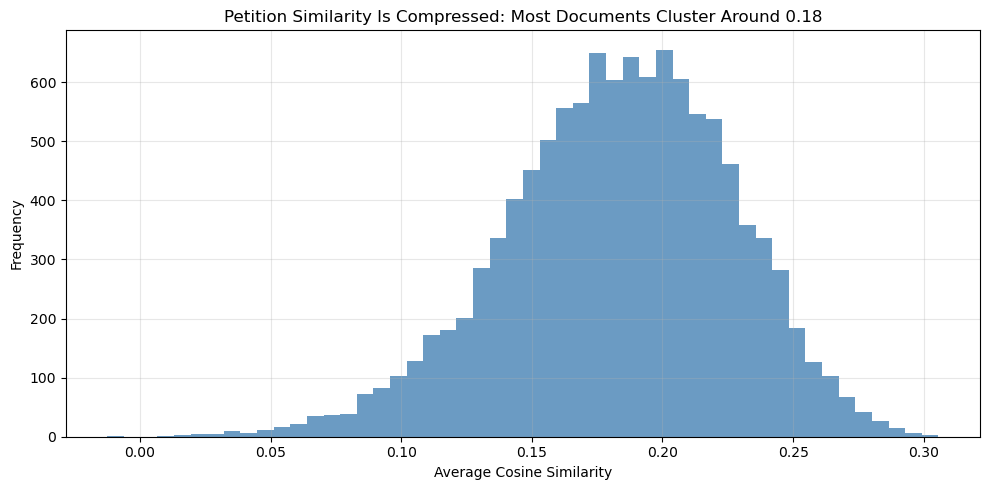

In [25]:
# Distribution of per-document average similarity
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(avg_similarity, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.set_xlabel('Average Cosine Similarity')
ax.set_ylabel('Frequency')
ax.set_title('Petition Similarity Is Compressed: Most Documents Cluster Around 0.18')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The distribution of average similarity scores is pretty compressed, ranging from roughly -0.01 to 0.31 with a standard deviation of only 0.04. Most petitions sit around 0.18, meaning the typical petition is weakly but consistently similar to the rest of the dataset. For context, cosine similarity of 1.0 means identical and 0.0 means no relationship, so 0.18 indicates that petitions share some common language and framing but are mostly about different things. Nobody is dramatically more mainstream or more niche than anyone else.

The fact that this clustering happens at the low end of the 0-1 scale is worth noting. Petitions are broadly dissimilar to each other, which makes sense: people petition about all kinds of different things. But they're not completely unrelated either, there's a baseline of shared language and framing that comes from the petition format itself ("we want the government to...", "this would help..."). The max of 0.31 tells us that even the most "mainstream" petition is still not that similar to the average petition. And the min sitting just below zero means there are a few petitions that are genuinely unlike anything else in the dataset, semantically speaking.

## A.4 Anomaly Detection

I'm using Isolation Forest on the TF-IDF vectors to detect lexically anomalous petitions. Isolation Forest works by randomly partitioning features with random splits, and the logic is that anomalies are easier to isolate (fewer splits needed) because they sit in sparse regions of the feature space. This is a good fit for the high-dimensional TF-IDF matrix because it splits on individual features rather than computing distances across the full space, so it doesn't suffer from the curse of dimensionality the way LOF or DBSCAN would.

I keep n_estimators at the default 100 trees, which is standard for Isolation Forest and sufficient for convergence on a dataset of this size. I set contamination to 0.05. I don't have a strong prior for what proportion of petitions use genuinely rare vocabulary, so I start conservative. A lower contamination prioritizes precision: I'd rather flag fewer petitions and be confident they're actually lexically unusual than cast a wide net and pick up petitions that are only slightly atypical.

In [26]:
# Isolation Forest on TF-IDF vectors

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

anomaly_labels = iso_forest.fit_predict(tfidf_matrix)
anomaly_scores = iso_forest.decision_function(tfidf_matrix)

# Separate structure: DataFrame with index, labels, scores
anomaly_df = pd.DataFrame({
    'index': range(len(anomaly_labels)),
    'label': anomaly_labels,        # 1 = normal, -1 = anomaly
    'score': anomaly_scores,         # lower = more anomalous
    'action': df['action'].values,
    'petition_concat': df['petition_concat'].values,
    'state': df['state'].values,
    'signature_count': df['signature_count'].values
})

n_anomalies = (anomaly_labels == -1).sum()
print(f"Anomalies flagged: {n_anomalies} ({n_anomalies/len(anomaly_labels)*100:.1f}%)")
print(f"Normal: {(anomaly_labels == 1).sum()}")
print(f"\nAnomaly score stats:")
print(f"  Mean:   {anomaly_scores.mean():.4f}")
print(f"  Min:    {anomaly_scores.min():.4f} (most anomalous)")
print(f"  Max:    {anomaly_scores.max():.4f} (most normal)")

Anomalies flagged: 555 (5.0%)
Normal: 10537

Anomaly score stats:
  Mean:   0.0104
  Min:    -0.0164 (most anomalous)
  Max:    0.0202 (most normal)


In [27]:
# Inspect the most anomalous petitions (lowest scores)
anomalies_only = anomaly_df[anomaly_df['label'] == -1].sort_values('score')

print("=== MOST ANOMALOUS (lowest scores) ===\n")
for _, row in anomalies_only.head(10).iterrows():
    print(f"Score: {row['score']:.4f} | State: {row['state']} | Sigs: {row['signature_count']}")
    print(f"Action: {row['action']}")
    print(f"Text: {row['petition_concat'][:300]}...")
    print()

print("\n=== LEAST ANOMALOUS among flagged (highest scores) ===\n")
for _, row in anomalies_only.tail(10).iterrows():
    print(f"Score: {row['score']:.4f} | State: {row['state']} | Sigs: {row['signature_count']}")
    print(f"Action: {row['action']}")
    print(f"Text: {row['petition_concat'][:300]}...")
    print()

=== MOST ANOMALOUS (lowest scores) ===

Score: -0.0164 | State: open | Sigs: 63
Action: Reassess CMS calculations to include assets and non-PAYE income for parents
Text: Reassess CMS calculations to include assets and non-PAYE income for parents We ask the Government to conduct a full review of Child Maintenance System calculation rules for parents who are self-employed or work outside the PAYE system. We request a modernised, transparent assessment framework reflec...

Score: -0.0164 | State: rejected | Sigs: 7
Action: Conduct a full investigation into the pakistani grooming gangs
Text: Conduct a full investigation into the pakistani grooming gangs We urge the Government to fully investigate Pakistani grooming gangs on behalf of UK Muslims.Justice for victims & addressing systemic failures in safeguarding is vital.A transparent inquiry will ensure accountability, support survivors,...

Score: -0.0154 | State: closed | Sigs: 10400
Action: Fund more staff training and better facilities 

Looking at the flagged anomalies, the pattern isn't one single thing. It's a mix of reasons petitions end up with rare vocabulary in the TF-IDF space:

Some use unusual formatting. For example, one petition's action reads "Review the laws surrounding e-bikes and e-scooters: • Speed limits • Age restrictions • Insurance requirements • Road usage rules" — the bullet point characters (•) and list-style structure, which produce tokens most petitions don't have.
Some are loaded with technical jargon. The CMS petition uses "PAYE", "non-PAYE income", "assessment framework," which is bureaucratic language that rarely shows up elsewhere in the corpus.
Some pack in dense proper nouns and domain-specific terms, like the grooming gangs petition with "Pakistani grooming gangs", "safeguarding", "accountability" in a run-on style.
Some have unusual structure, like the civic responsibility petition which reads more like a policy document ("In three parts: 1)... 2)... 3)...") than a typical petition.

What they all share is that their word choices are rare relative to the rest of the corpus. Most petitions follow a fairly standard "we want the government to..." framing with common policy language. These ones break that mould in different ways, which is exactly what TF-IDF based anomaly detection should be picking up.

In [28]:
# Scatter plot: anomaly scores with anomalies highlighted
 
anomaly_df['label_name'] = anomaly_df['label'].map({1: 'Normal', -1: 'Anomaly'})
 
fig = px.scatter(
    anomaly_df,
    x='index',
    y='score',
    color='label_name',
    color_discrete_map={'Normal': 'steelblue', 'Anomaly': 'red'},
    hover_data=['action', 'state', 'signature_count'],
    title='Lexical Anomalies Are Scattered Across the Dataset With No Positional Pattern',
    labels={'index': 'Petition Index', 'score': 'Anomaly Score (lower = more anomalous)', 'label_name': ''},
    opacity=0.5
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=500)
fig.show()
 

Anomalous petitions appear randomly scattered across petition index, which is a good sign. The inspection of flagged anomalies above confirms that anomalous petitions tend to use more specific nouns and technical vocabulary than typical petitions, which is intuitive since we chose a lexical measure. Petitions that have strange format, like bullet points or other would also be placed in anomalies, but I see very few here. Lets look at state and sig count on anomalous petitions to see if we can spot a pattern.

In [29]:
# Anomaly breakdown by state
anomalies_only = anomaly_df[anomaly_df['label'] == -1]
normal_only = anomaly_df[anomaly_df['label'] == 1]
 
print("=== State distribution ===")
print("\nAnomalies:")
print(anomalies_only['state'].value_counts(normalize=True).round(3))
print("\nNormal:")
print(normal_only['state'].value_counts(normalize=True).round(3))
 
print("\n=== Signature count stats ===")
print("\nAnomalies:")
print(anomalies_only['signature_count'].describe().round(1))
print("\nNormal:")
print(normal_only['signature_count'].describe().round(1))
 

=== State distribution ===

Anomalies:
state
rejected    0.550
closed      0.249
open        0.202
Name: proportion, dtype: float64

Normal:
state
rejected    0.555
closed      0.276
open        0.170
Name: proportion, dtype: float64

=== Signature count stats ===

Anomalies:
count       555.0
mean       2871.8
std       26337.4
min           6.0
25%           8.0
50%          21.0
75%         101.0
max      550137.0
Name: signature_count, dtype: float64

Normal:
count      10537.0
mean        1821.4
std        32441.0
min            4.0
25%            7.0
50%           21.0
75%           78.0
max      2984192.0
Name: signature_count, dtype: float64


Breaking down the anomalies by state and signature count, the distributions are basically identical to the normal petitions. Rejected petitions make up about 55% of both groups, and the signature stats are similar across the board. This suggests that lexical anomalies aren't picking up on some structural feature of the data like petition success or rejection. These petitions are anomalous purely in how they're written, not in their outcomes or popularity. My takeaway is that isolation forest is properly flagging petitions with anomalous lexical patterns. 

## A.5 Comparison: Similarity vs. Anomaly Perspectives

The whole point of using two different signals was to see what each perspective reveals that the other doesn't. Now I want to look among lexical anomalies, and see if they about mainstream or niche topics, and also among the most semantically mainstream petitionsto see if any of those are written unusually. 

In [30]:
# Add average similarity to the anomaly dataframe for comparison
anomaly_df['avg_similarity'] = avg_similarity

# Question 1: Among lexical anomalies, what's their semantic similarity profile?
print("=== Avg similarity: anomalies vs normal ===\n")
print("Anomalies:")
print(anomaly_df[anomaly_df['label'] == -1]['avg_similarity'].describe().round(4))
print("\nNormal:")
print(anomaly_df[anomaly_df['label'] == 1]['avg_similarity'].describe().round(4))

=== Avg similarity: anomalies vs normal ===

Anomalies:
count    555.0000
mean       0.1921
std        0.0415
min        0.0551
25%        0.1638
50%        0.1956
75%        0.2225
max        0.2858
Name: avg_similarity, dtype: float64

Normal:
count    10537.0000
mean         0.1825
std          0.0434
min         -0.0124
25%          0.1544
50%          0.1849
75%          0.2137
max          0.3056
Name: avg_similarity, dtype: float64


In [31]:
# Question 2: Among the most semantically mainstream petitions (top 5% avg similarity),
# how many are lexically anomalous?
top_5_pct = np.percentile(avg_similarity, 95)
mainstream = anomaly_df[anomaly_df['avg_similarity'] >= top_5_pct]

n_mainstream_anomalies = (mainstream['label'] == -1).sum()
n_mainstream_total = len(mainstream)

print(f"=== Mainstream petitions (top 5% avg similarity, >= {top_5_pct:.4f}) ===\n")
print(f"Total: {n_mainstream_total}")
print(f"Flagged as lexical anomalies: {n_mainstream_anomalies} ({n_mainstream_anomalies/n_mainstream_total*100:.1f}%)")

if n_mainstream_anomalies > 0:
    print(f"\nThese mainstream-but-anomalous petitions:")
    for _, row in mainstream[mainstream['label'] == -1].iterrows():
        print(f"\n  Score: {row['score']:.4f} | Avg sim: {row['avg_similarity']:.4f} | Sigs: {row['signature_count']}")
        print(f"  Action: {row['action']}")
        print(f"  Text: {row['petition_concat'][:300]}...")

=== Mainstream petitions (top 5% avg similarity, >= 0.2487) ===

Total: 555
Flagged as lexical anomalies: 38 (6.8%)

These mainstream-but-anomalous petitions:

  Score: -0.0005 | Avg sim: 0.2508 | Sigs: 7
  Action: Properly address and stop the shortage of vets in the UK
  Text: Properly address and stop the shortage of vets in the UK In a 21st century Britain, NO ONE, animal or human, should be denied help and care simply because of staff shortages, brought on by the failed promises of a past government. This is a national issue that CANNOT go on any longer like this! A fu...

  Score: -0.0013 | Avg sim: 0.2775 | Sigs: 346
  Action: Reform the Public Health Act to prevent future lockdowns without MP's scrutiny
  Text: Reform the Public Health Act to prevent future lockdowns without MP's scrutiny Replace emergency procedures in the Public Health Act 1984 (including the section 45R, the urgency procedure that allows a single minister to implement emergency legislation), with revised leg

The two analyses pick up different things. That's kind of the whole point. Lexical anomalies actually have a slightly higher average semantic similarity (0.192) than normal petitions (0.183), which, if anything, means the weird-sounding ones are about more normal stuff. Also, if you look at the top 5% most semantically mainstream petitions, 6.8% of them are lexical anomalies, which is above the 5% base rate. So yeah. Mainstream topics attract more unusual writing. Not the other way around.

Basically semantic similarity and lexical anomaly are just measuring different things. Writing weird doesn't mean you're writing about weird stuff. The anomalous petitions aren't like, unhinged rants about niche conspiracy topics. They're about animal welfare and the NHS and school fees and buses. Normal stuff. They just happen to use technical language or strange formatting or read like policy documents instead of starting with "we want the government to..." The two signals don't really overlap, which is why using both was worth it anyway. 

---
# Part B: Research Question

## B.1 Question and Reasoning

### Reasoning
Part A showed that petition language is semantically homogeneous and that lexical anomalies are independent of topic. Part A never actually touched what petitions are about though, which left a gap worth exploring. To build a research question around topic groups I needed to understand what the petition states actually mean in terms of the petition lifecycle. Rejected petitions are ones that failed moderation by the Petitions Committee. Open petitions passed moderation and are currently live for six months collecting signatures. Closed petitions are everything that ran its course, but that's a heterogeneous category because a petition with 12 signatures and one debated in Parliament both end up labelled "closed." There's also no "accepted by government" state in the data. The meaningful thresholds are at 10,000 signatures, where the government must respond in writing, and 100,000, where the Petitions Committee considers scheduling a debate. Understanding this lifecycle made me realize that state alone isn't enough to measure engagement, and that splitting on signature thresholds within topics would give a more useful picture. So I ended up with two comparison layers: rejected vs opened as a moderation com

### Question
I want to establish clearer topic groups within petitions to assess what issues have high vs low engagement based on signature and petition counts. Then, within those topic groups I want to compare lexical patterns within rejected vs opened petitions and also between petitions split by signature count thresholds to see if lexical patterns have correlation with petition moderation and public engagement, respectively. This question aims to fill gaps left by the work done in Part A, where I established that petition language is homogeneous but that outliers do exist. I want to do a deeper dive because I suspect that true signal in petition text requires deeper analysis.

### Method Selection
I chose BERTopic as my first method because I don't understand the groups in the data well enough to specify a topic count upfront, which rules out LDA. BERTopic determines topic count automatically through its internal HDBSCAN clustering, so it lets the data determine its own groupings. I did consider running standalone clustering as a separate method, but BERTopic already handles clustering internally, and adding another layer of clustering on top of that didn't have a clear analytical purpose.

BERTopic alone only counts as one technique for the assignment though, so I needed a second method. Keyness analysis (log-likelihood) fills that role, and the reason it adds genuine analytical value rather than just satisfying a requirement is that it compares groups I define myself based on a meaningful distinction, not groups the algorithm already labeled. BERTopic tells me what the topic groups are. Keyness then tells me how language differs between petition states and engagement levels within those topic groups. The two methods answer different questions and complement each other: BERTopic provides the topical structure, and keyness provides the comparative lens on language within that structure.

## B.2 Topic Analysis

### Parameter Tuning Decisions
BERTopic has several internal components that need configuring: UMAP for dimensionality reduction, HDBSCAN for clustering, and a CountVectorizer for generating topic labels via c-TF-IDF. I locked in some of these decisions upfront based on what I already knew about the data. I'm reusing the all-MiniLM-L6-v2 sentence embeddings from Part A, since it's the same model on the same data and the identical embedding space lets me cross-reference between parts if needed. For the CountVectorizer, I'm removing stopwords, setting max_df=0.8 as a safety net on top of stopword removal, and ngram_range=(1,2) because bigrams like "illegal immigrants" signal a different issue than either word alone. I originally planned min_df=50 so a word would need to appear in at least 50 petitions, but c-TF-IDF operates at the topic level where each "document" is all petitions in a topic concatenated together. With 55 topics, min_df=50 was impossible. I set min_df=3, meaning a word must appear in at least 3 topic-documents to make it into labels.

The parameters I couldn't decide upfront are UMAP's n_neighbors and n_components, and HDBSCAN's min_cluster_size. UMAP controls how much structure from the high-dimensional embedding space gets preserved when compressing to fewer dimensions. I want to preserve topic groups and lose the noise, but how aggressively to compress is hard to reason about without seeing what comes out the other end. HDBSCAN's min_cluster_size sets the smallest group of documents that can form a topic, which matters because my research question needs topic groups large enough to support meaningful keyness comparisons between petition states within each group. A topic with five documents can't tell me anything useful about how rejected and opened petitions differ lexically.

Both are hard to set without seeing the output, so I'm starting with BERTopic's defaults, running the full pipeline, and adjusting based on what the topics look like.

In [32]:
# UMAP with BERTopic defaults — tuning after inspecting output
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# HDBSCAN with defaults — min_cluster_size to be tuned
hdbscan_model = HDBSCAN(min_cluster_size=50, metric='euclidean', cluster_selection_method='eom')

# CountVectorizer for c-TF-IDF topic labels
vectorizer_model = CountVectorizer(stop_words='english', min_df=3, max_df=0.8, ngram_range=(1, 2))

# BERTopic — passing precomputed embeddings, no automatic topic merging
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

# Fit using raw text for c-TF-IDF, precomputed embeddings for clustering
docs = df['petition_concat'].tolist()
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

2026-04-28 15:42:43,577 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-28 15:42:59,087 - BERTopic - Dimensionality - Completed ✓
2026-04-28 15:42:59,091 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-28 15:42:59,278 - BERTopic - Cluster - Completed ✓
2026-04-28 15:42:59,289 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-28 15:43:00,270 - BERTopic - Representation - Completed ✓


In [33]:
# How many topics, and how many documents in each
print(topic_model.get_topic_info())

# How many outliers (topic -1)
print(f"\nOutlier count: {sum(1 for t in topics if t == -1)}")
print(f"Outlier %: {sum(1 for t in topics if t == -1) / len(topics) * 100:.1f}%")

    Topic  Count                                            Name  \
0      -1   3136                     -1_care_nhs_parents_schools   
1       0    583                    0_housing_water_energy_homes   
2       1    499                  1_abuse_victims_child_domestic   
3       2    454                       2_dogs_animal_animals_dog   
4       3    426     3_election_general election_confidence_vote   
5       4    376                        4_ilr_visa_skilled_route   
6       5    319         5_illegal_asylum_immigrants_immigration   
7       6    303                   6_food_plastic_products_waste   
8       7    270                     7_knife_crime_police_knives   
9       8    226                    8_animals_sale_displays_pets   
10      9    202                    9_schools_autism_school_send   
11     10    190            10_social media_media_online_content   
12     11    186                    11_speed_road_cyclists_roads   
13     12    179        12_gangs_grooming_inquir

### Tuning

I started with BERTopic's default parameters to get a baseline: n_neighbors=15, n_components=5, min_dist=0.0 for UMAP, and min_cluster_size=10 for HDBSCAN. The first run produced 229 topics with most of them containing only 10 documents and 21.9% of petitions ending up as outliers (topic -1, meaning HDBSCAN couldn't confidently assign them to any cluster). That's far too granular. A topic group of 10 petitions can't support the keyness comparisons I need downstream, where I'll be splitting topics further by petition state and signature thresholds.

I bumped min_cluster_size to 50, which tells HDBSCAN that a group needs at least 50 documents to count as a topic. This produced 55 topics covering things like housing, abuse, animals, elections, immigration, NHS, and schools. Outliers rose to 29.6%, which makes sense since documents that previously formed small niche clusters now get pushed into the unassigned pool instead.

I then looked at whether UMAP tuning could help. At n_neighbors=15, a few topic pairs looked like they might be fragments of the same group. The clearest case was two separate NHS topics, one about prescriptions and treatment, the other about hospitals and care. n_neighbors controls how much local vs global structure UMAP preserves, so increasing it should push related topics closer together in the reduced space. I ran n_neighbors=30 and the NHS topics did merge, but Ukraine/Russia and Gaza/Israel also merged into a single topic. Those are very different issues, both in terms of what the petitions are asking for and who's signing them. The roads and driving topics also collapsed into one 724-document catch-all. I tried n_neighbors=23 as a middle ground but it kept the Ukraine/Gaza merge. The NHS merge wasn't worth that tradeoff, so I went back to n_neighbors=15.

The remaining splits in the output are defensible. The two NHS topics cover prescriptions vs hospital infrastructure, which are different policy asks. The two MPs topics are about accountability in one case and financial perks in the other. I'd rather have those as separate topics than force merges that combine unrelated petitions.

### BERTopic Output Assessment
Topics 46 and 6 look fishy. 46 looks like a lot of different topics jumbled together and topic 6 looks like it might be about plastic waste and something food related, which could mean that our model conflated two into one here. 

In [34]:
df['topic'] = topics

for t in [46, 6]:
    subset = df[df['topic'] == t]
    print(f"\n=== Topic {t} — {len(subset)} docs, {subset['signature_count'].sum()} total sigs ===")
    print(f"States: {subset['state'].value_counts().to_dict()}")
    print()
    for _, row in subset.head(10).iterrows():
        print(f"[{row['state']}, {row['signature_count']} sigs] {row['action'][:120]}")
        print()


=== Topic 46 — 60 docs, 749 total sigs ===
States: {'rejected': 57, 'closed': 3}

[rejected, 8 sigs] Give David Tennant a Knightship

[rejected, 21 sigs] Make “always look on the bright side of live (clean)” the new national anthem

[rejected, 6 sigs] Change the uk national anthem from 'God save the king' to 'Rule Britannia'

[rejected, 10 sigs] Change the national anthem to The Imperial March.

[rejected, 7 sigs] Make loved British singer Elkie Brooks a DAME.

[rejected, 6 sigs] Sadiq Khan MUST NOT be given a knight hood.

[rejected, 10 sigs] Stop Sadiq Khans proposed Knighthood

[rejected, 21 sigs] Sadiq Khan does not deserve a knighthood.

[rejected, 6 sigs] Stop Sadiq Khan from being Knighted,

[rejected, 7 sigs] Refuse Sadiq Khan's Knighthood


=== Topic 6 — 303 docs, 187800 total sigs ===
States: {'rejected': 127, 'closed': 107, 'open': 69}

[closed, 10322 sigs] Require landfills that cause smells and toxins near residential areas to close

[rejected, 7 sigs] Standardise grocery

Topic 46 is coherent. The petitions inside are coherent and adress knighthood as an issue. Pretty humorous actually, and its also a very small topic with only 738 total sigs. Topic 6 is a different story. It is a broad heterogenous mixture of different public safety concerns, ranging from grocery packages, waste management, consumer protection laws, and who knows what else. This topic has 186,399 total sigs, making it the 6th largest topic in our set. I think its worth keeping around for the topical analysis since it represents to much data and can be broadly categorized as 'public safety and wellbeing concerns'. It should be left alone or used but only with serious caveats in keyness analysis as the heterogeneity will make lexical findings noisy.

In [35]:
# sig count and petition count per topic
topic_stats = df[df['topic'] != -1].groupby('topic').agg(
    petition_count=('petition_id', 'count'),
    total_sigs=('signature_count', 'sum'),
    label=('topic', 'first')
).reset_index()

topic_names = topic_model.get_topic_info()[['Topic', 'Name']].rename(columns={'Topic': 'topic'})
topic_stats = topic_stats.merge(topic_names, on='topic')

fig = px.scatter(
    topic_stats, x='petition_count', y='total_sigs',
    hover_name='Name', hover_data=['topic', 'petition_count', 'total_sigs'],
    labels={'petition_count': 'Petition Count', 'total_sigs': 'Total Signatures'},
    title='Most Topics Cluster at Low Counts; A Few Break Out on Signatures or Petitions'
)
fig.update_traces(marker=dict(size=8))
fig.update_layout(width=900, height=600)
fig.show()

Most topics sit in a tight cluster in the bottom left with low petition counts and low total signatures. A handful break out. Immigration and animals have both high petition counts and high signature totals. Digital ID (topic 28) is a weird one: only 104 petitions but nearly 3 million signatures, almost double the next highest topic. That means a small number of petitions on that issue captured massive public attention. On the other end, topics like honours (topic 46) and school weekends (topic 49) barely register on either metric. Topic 6 (public safety) is interesting because it has 300 petitions but only 186k total signatures, so lots of people raising concerns but not much traction per petition. There seems to be more spread on the petition count axis than on signatures. To check whether the high-sig outlier topics are being driven by individual mega-petitions or broader engagement, and to get a better read on per-petition engagement intensity, I ran a few follow-up checks below.

=== Median Signature Count Per Topic (top 15 and bottom 15) ===
topic
27    69.0
24    57.0
40    53.5
32    40.0
9     40.0
49    39.0
1     38.0
21    37.0
34    34.5
6     34.0
2     32.0
36    29.0
29    23.5
11    23.0
45    22.0
Name: signature_count, dtype: float64

...
topic
5     11.0
14    11.0
8     10.0
28    10.0
25    10.0
12    10.0
38    10.0
51     9.0
52     9.0
37     8.0
48     8.0
20     8.0
3      8.0
43     7.0
46     7.0
Name: signature_count, dtype: float64


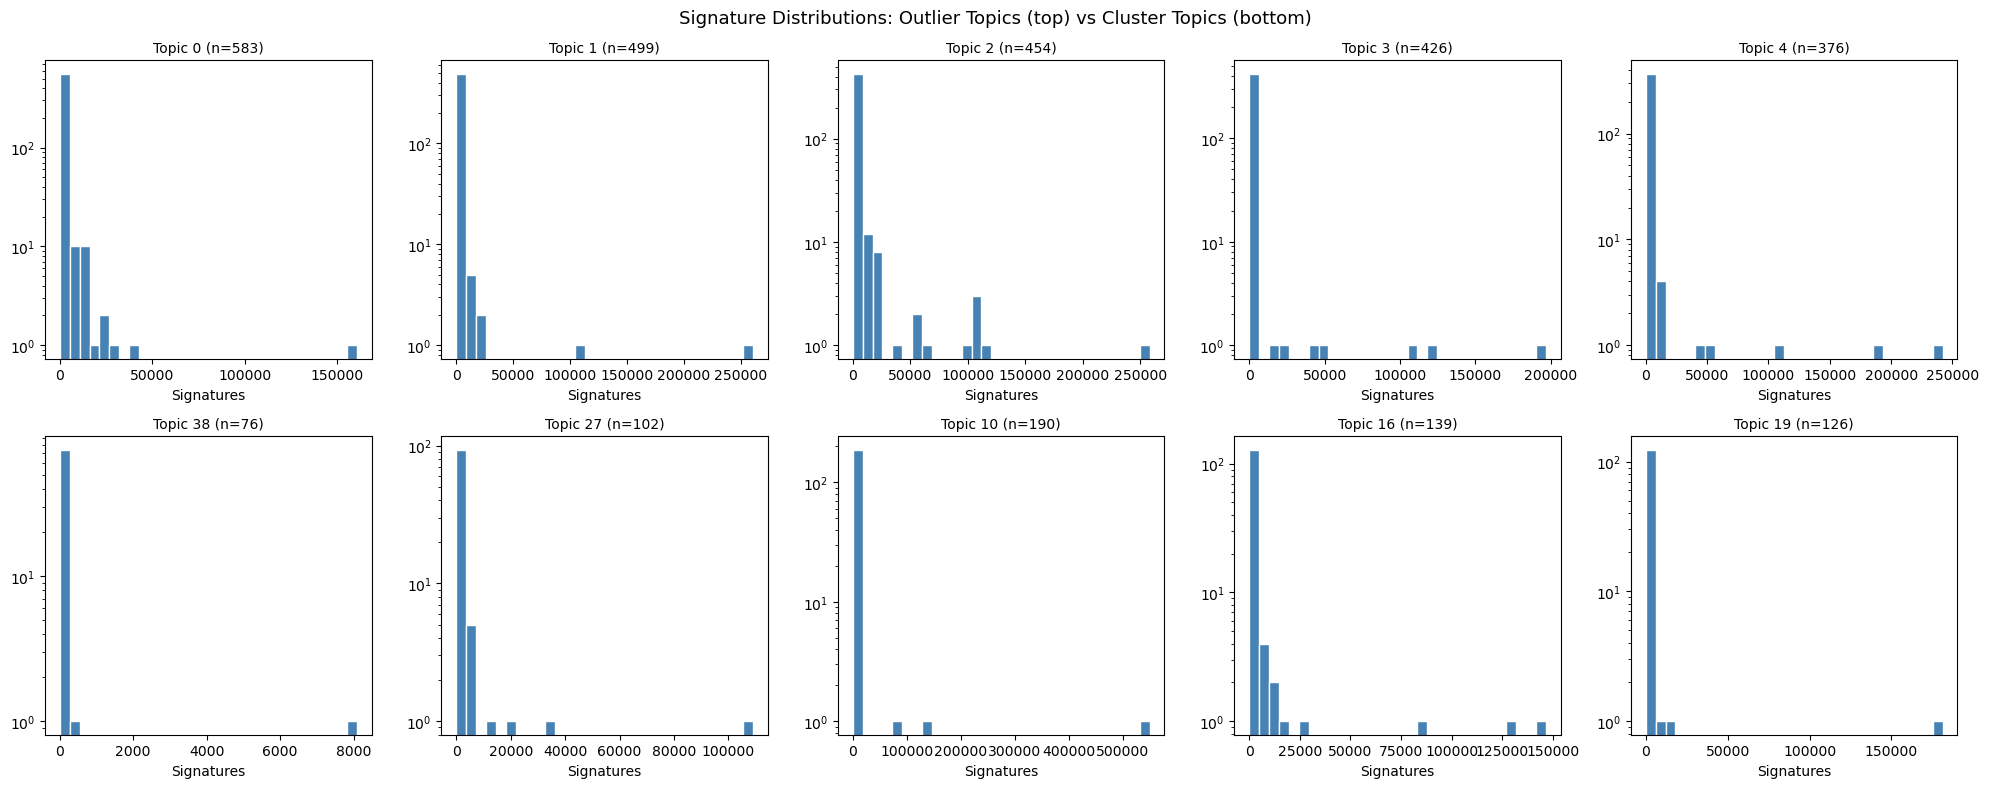


=== Topic 28 (Digital ID) — Top 10 petitions by signature count ===
[closed, 2,984,192 sigs] Do not introduce Digital ID cards
[closed, 24,137 sigs] Hold a referendum on introducing mandatory identity cards in the UK
[open, 15,301 sigs] Protect the Right to Live Without a Digital ID
[closed, 2,228 sigs] Stop the roll out and use of trusted digital identity services
[closed, 862 sigs] Do not introduce digital driving licences
[open, 328 sigs] Call for full scrutiny & a 6 month public consultation on Digital ID

[closed, 273 sigs] Reintroduce UK National ID cards for British citizens.
[open, 266 sigs] Allow all EU, EEA and Swiss nationals to enter UK with ID card
[open, 256 sigs] Do not roll out digital IDs
[open, 200 sigs] Abolish fees for passport name changes

Total sigs: 3,029,868
Top petition's share: 98.5%


In [36]:
# 1. Median signature count per topic, sorted
median_sigs = df[df['topic'] != -1].groupby('topic')['signature_count'].median().sort_values(ascending=False)
print("=== Median Signature Count Per Topic (top 15 and bottom 15) ===")
print(median_sigs.head(15))
print("\n...")
print(median_sigs.tail(15))

# 2. Sig count distributions, sample of outlier and cluster topics
random.seed(42)
breakout_topics = [0, 1, 2, 3, 4, 5, 6, 7, 8, 28]
cluster_topics = [t for t in df[df['topic'] != -1]['topic'].unique() if t not in breakout_topics]
sample_cluster = random.sample(cluster_topics, 5)
sample_topics = breakout_topics[:5] + sample_cluster  # 5 outliers + 5 cluster

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
for ax, t in zip(axes.flatten(), sample_topics):
    subset = df[df['topic'] == t]['signature_count']
    ax.hist(subset, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f"Topic {t} (n={len(subset)})", fontsize=10)
    ax.set_xlabel('Signatures')
    ax.set_yscale('log')
plt.suptitle('Signature Distributions: Outlier Topics (top) vs Cluster Topics (bottom)', fontsize=13)
plt.tight_layout()
plt.show()

# 3. Digital ID deep dive
t28 = df[df['topic'] == 28].sort_values('signature_count', ascending=False)
print("\n=== Topic 28 (Digital ID) — Top 10 petitions by signature count ===")
for _, row in t28.head(10).iterrows():
    print(f"[{row['state']}, {row['signature_count']:,} sigs] {row['action'][:120]}")
print(f"\nTotal sigs: {t28['signature_count'].sum():,}")
print(f"Top petition's share: {t28['signature_count'].iloc[0] / t28['signature_count'].sum():.1%}")

# 4. Engagement intensity scatter, avg sigs per petition per topic
topic_stats['avg_sigs'] = topic_stats['total_sigs'] / topic_stats['petition_count']

fig = px.scatter(
    topic_stats, x='petition_count', y='avg_sigs',
    hover_name='Name', hover_data=['topic', 'petition_count', 'total_sigs', 'avg_sigs'],
    labels={'petition_count': 'Petition Count', 'avg_sigs': 'Avg Signatures Per Petition'},
    title='Topic Engagement Intensity: Petition Count vs Avg Signatures Per Petition'
)
fig.update_traces(marker=dict(size=8))
fig.update_layout(width=900, height=600)
fig.show()

Looking at median signature counts per topic tells a different story than total signatures. Topics like NHS prescriptions (topic 18) and women's fertility (topic 30) have high medians, meaning the typical petition in those topics gets decent traction. Meanwhile digital ID (topic 28) has a median of just 9.5 despite having 3 million total signatures. That 3 million is almost entirely one petition: "Do not introduce Digital ID cards" accounts for 98.5% of the topic's total signatures. Most topics work the same way, with the majority of petitions sitting well under 50k.

The engagement intensity scatter (average signatures per petition per topic) reshuffles the rankings. Gaza (topic 32) jumps to second place because its 89 petitions average nearly 6k signatures each. Housing (topic 0) drops despite having the most petitions (576) because the average petition only gets about 1,090 signatures. Topics like abuse/victims (topic 1) and general elections (topic 3) have lots of petitions but relatively low per-petition engagement.

Looking at signature distributions within topics, the cluster topics appear stratified. Certain topics have petitions breaking past 20k and also tend to have petitions around 100k, while others never break past a few thousand. The distributions suggest thresholds at which petitions jump, finding a step increase and then a plateau rather than a smooth curve. To check whether this holds up beyond the sampled histograms I ran an ECDF and histogram across all cluster-topic petitions.

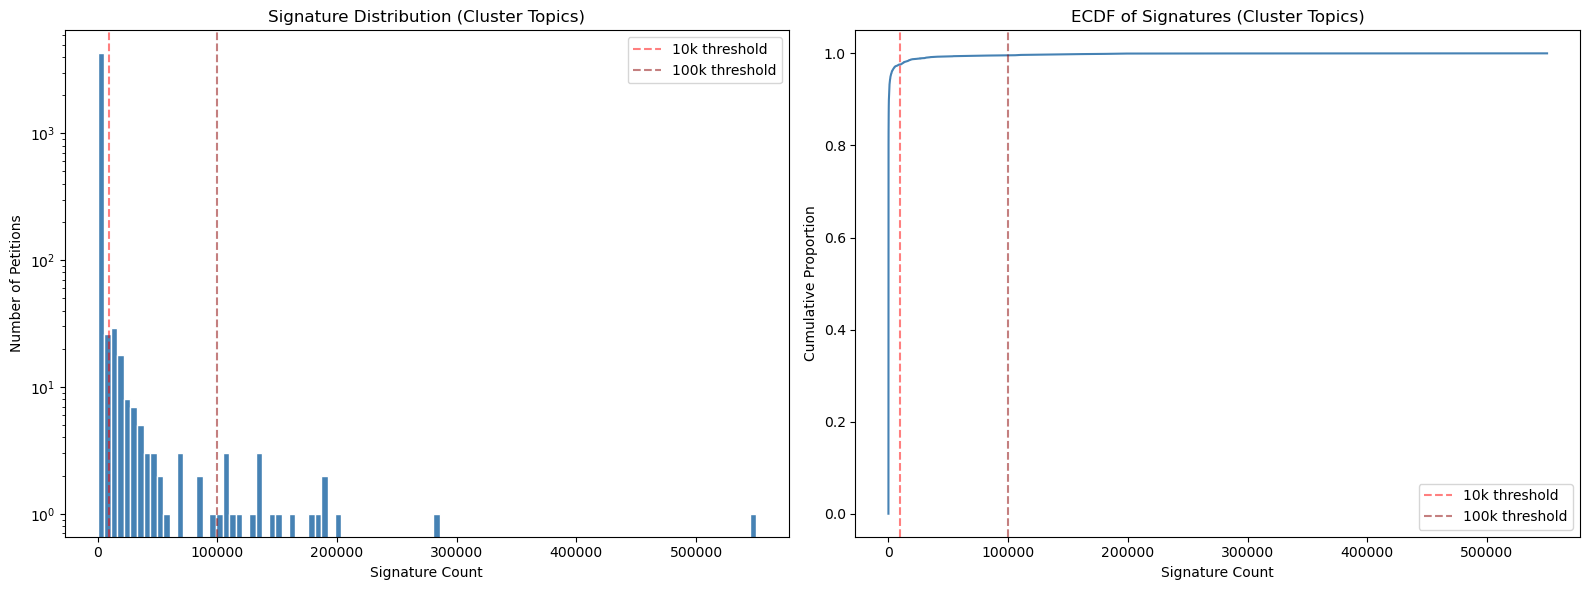

93.6% of cluster-topic petitions have <= 1,000 sigs
96.9% of cluster-topic petitions have <= 5,000 sigs
97.6% of cluster-topic petitions have <= 10,000 sigs
98.7% of cluster-topic petitions have <= 20,000 sigs
99.3% of cluster-topic petitions have <= 50,000 sigs
99.5% of cluster-topic petitions have <= 100,000 sigs


In [37]:
non_outlier = df[(~df['topic'].isin(breakout_topics)) & (df['topic'] != -1)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram — log scale on both axes for spread
axes[0].hist(non_outlier['signature_count'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Signature Count')
axes[0].set_ylabel('Number of Petitions')
axes[0].set_title('Signature Distribution (Cluster Topics)')
axes[0].axvline(x=10000, color='red', linestyle='--', alpha=0.5, label='10k threshold')
axes[0].axvline(x=100000, color='darkred', linestyle='--', alpha=0.5, label='100k threshold')
axes[0].legend()

# ECDF
sorted_sigs = np.sort(non_outlier['signature_count'].values)
ecdf = np.arange(1, len(sorted_sigs) + 1) / len(sorted_sigs)
axes[1].plot(sorted_sigs, ecdf, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Signature Count')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('ECDF of Signatures (Cluster Topics)')
axes[1].axvline(x=10000, color='red', linestyle='--', alpha=0.5, label='10k threshold')
axes[1].axvline(x=100000, color='darkred', linestyle='--', alpha=0.5, label='100k threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print proportions at key thresholds
for t in [1000, 5000, 10000, 20000, 50000, 100000]:
    pct = (non_outlier['signature_count'] <= t).mean()
    print(f"{pct:.1%} of cluster-topic petitions have <= {t:,} sigs")

The ECDF and histogram for cluster topics confirm what the per-topic histograms suggested. The vast majority of petitions sit well under 10k signatures, with the curve shooting up almost vertically near zero. There is a small bump around 110k in the histogram but it is only a handful of petitions, not enough to signal any real threshold or stratification in engagement. The outlier topics show a similar shape. The step pattern I noticed in the sampled per-topic histograms does not hold up as a systematic finding across the full set of cluster topics. Next I want to look at petition state distributions within topics and compare that to sign counts.

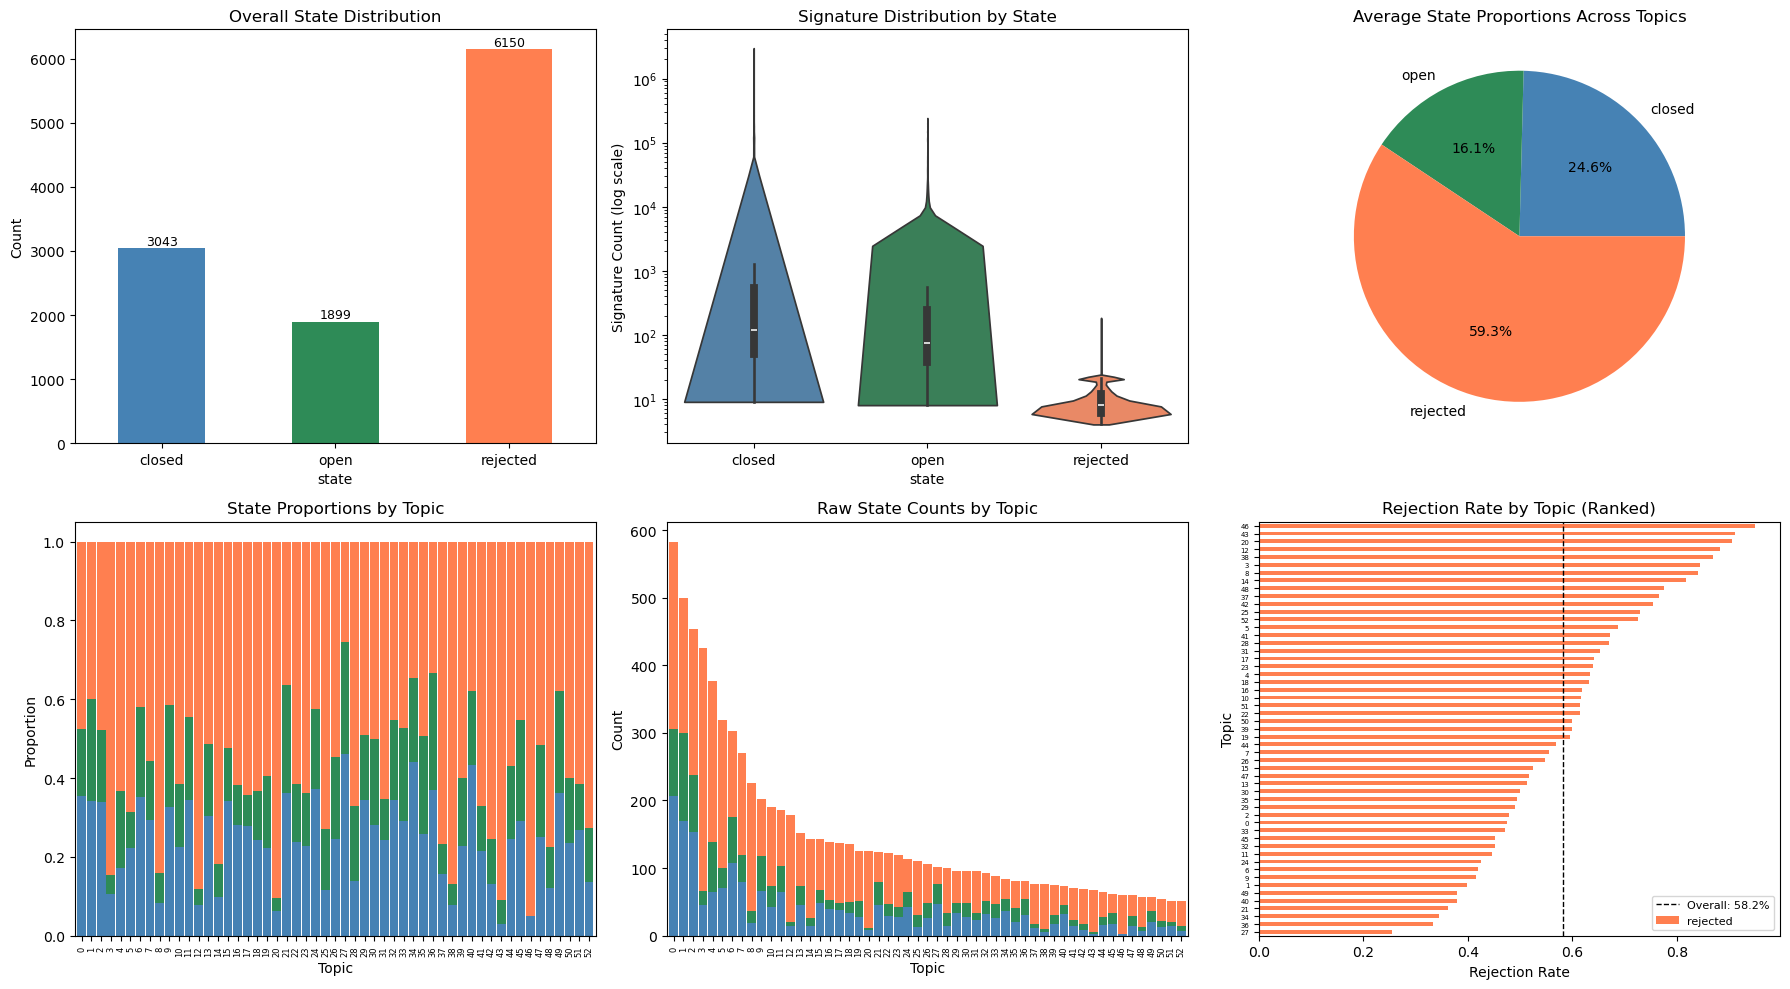


--- State Counts Overall ---
state
closed      3043
open        1899
rejected    6150
Name: count, dtype: int64

Overall rejection rate: 58.2%

--- Topics with highest rejection rates ---
  Topic 37 (37_football_sports_fans_league): 76.6%
  Topic 48 (48_school_weekend_week_days): 77.6%
  Topic 14 (14_elections_local_local elections_london): 81.8%
  Topic 8 (8_animals_sale_displays_pets): 84.1%
  Topic 3 (3_election_general election_confidence_vote): 84.5%
  Topic 38 (38_jury_trial_trials_justice): 86.8%
  Topic 12 (12_gangs_grooming_inquiry_grooming gangs): 88.3%
  Topic 20 (20_mps_expenses_heating_second): 90.5%
  Topic 43 (43_manifesto_promises_manifestos_election): 91.0%
  Topic 46 (46_god_king_honours_rob): 95.0%

--- Topics with lowest rejection rates ---
  Topic 27 (27_patients_nhs_medication_treatment): 25.5%
  Topic 36 (36_cash_customers_payment_service): 33.3%
  Topic 34 (34_veterans_armed_forces_armed forces): 34.5%
  Topic 21 (21_pension_state pension_pensioners_pensions): 

In [38]:
# Consistent color mapping: blue=closed, green=open, orange=rejected
state_colors = {'closed': 'steelblue', 'open': 'seagreen', 'rejected': 'coral'}
state_order = ['closed', 'open', 'rejected']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall state distribution (bar chart)
state_counts = df['state'].value_counts().reindex(state_order)
state_counts.plot(kind='bar', ax=axes[0, 0], color=[state_colors[s] for s in state_order])
axes[0, 0].set_title('Overall State Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)
for i, v in enumerate(state_counts):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontsize=9)

# 2. Signature distribution by state (violin plot, log scale)
sns.violinplot(data=df, x='state', y='signature_count', order=state_order,
               palette=state_colors, ax=axes[0, 1], cut=0)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Signature Distribution by State')
axes[0, 1].set_ylabel('Signature Count (log scale)')

# 3. Average state proportions across all topics (pie chart)
topic_df = df[df['topic'] != -1]
state_props = topic_df.groupby('topic')['state'].value_counts(normalize=True).unstack(fill_value=0)
state_props = state_props.reindex(columns=state_order, fill_value=0)
avg_props = state_props.mean()
axes[0, 2].pie(avg_props, labels=avg_props.index, autopct='%.1f%%',
               colors=[state_colors[s] for s in state_order])
axes[0, 2].set_title('Average State Proportions Across Topics')

# 4. State proportions per topic (stacked bar)
state_props_sorted = state_props.sort_index()
state_props_sorted.plot(kind='bar', stacked=True, ax=axes[1, 0],
                         color=[state_colors[s] for s in state_order], legend=False, width=0.9)
axes[1, 0].set_title('State Proportions by Topic')
axes[1, 0].set_xlabel('Topic')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].tick_params(axis='x', labelsize=6)

# 5. Raw state counts per topic (stacked bar)
state_raw = topic_df.groupby('topic')['state'].value_counts().unstack(fill_value=0)
state_raw = state_raw.reindex(columns=state_order, fill_value=0)
state_raw_sorted = state_raw.sort_index()
state_raw_sorted.plot(kind='bar', stacked=True, ax=axes[1, 1],
                       color=[state_colors[s] for s in state_order], legend=False, width=0.9)
axes[1, 1].set_title('Raw State Counts by Topic')
axes[1, 1].set_xlabel('Topic')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', labelsize=6)

# 6. Rejection rate per topic (ranked)
rejection_rates = state_props['rejected'].sort_values(ascending=True)
overall_rejection_rate = (topic_df['state'] == 'rejected').mean()
rejection_rates.plot(kind='barh', ax=axes[1, 2], color='coral')
axes[1, 2].axvline(overall_rejection_rate, color='black', linestyle='--', linewidth=1,
                     label=f'Overall: {overall_rejection_rate:.1%}')
axes[1, 2].set_title('Rejection Rate by Topic (Ranked)')
axes[1, 2].set_xlabel('Rejection Rate')
axes[1, 2].set_ylabel('Topic')
axes[1, 2].legend(fontsize=8)
axes[1, 2].tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.show()

topic_info = topic_model.get_topic_info()
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

print("\n--- State Counts Overall ---")
print(state_counts)
print(f"\nOverall rejection rate: {overall_rejection_rate:.1%}")
print(f"\n--- Topics with highest rejection rates ---")
for topic, rate in rejection_rates.tail(10).items():
    print(f"  Topic {topic} ({topic_name_map.get(topic, '?')}): {rate:.1%}")

print(f"\n--- Topics with lowest rejection rates ---")
for topic, rate in rejection_rates.head(10).items():
    print(f"  Topic {topic} ({topic_name_map.get(topic, '?')}): {rate:.1%}")

To understand how petition outcomes distribute across the topic groups, I ran a set of diagnostic visualisations looking at state labels (closed, open, rejected) from several angles.
The overall state distribution is dominated by rejected petitions at 6,150 out of 11,092 non-outlier petitions, with closed at 3,043 and open at 1,899. That puts the overall rejection rate at 58.2%. The signature distribution by state shows that rejected petitions cluster tightly at very low signature counts, which makes sense given that petitions are either discarded before they can accumulate signatures or are low quality enough that they don't attract signers. Closed and open petitions both have much wider distributions, though comparing those two directly is limited by the fact that open petitions are still collecting signatures while closed petitions have finished their lifecycle.

The average state proportions across all 55 topics come out to 58.7% rejected, 25.3% closed, and 16.0% open. That average is close to the overall dataset rate of 58.2%.

This near-match is worth pausing on. The pie chart weights each topic equally while the overall rate weights each petition equally. These two numbers would only converge if topic size and rejection rate were uncorrelated. The fact that they nearly do confirms that larger topics are not systematically more or less likely to be rejected than smaller ones.

Looking at per-topic rejection rates ranked from lowest to highest, there is significant variance. The lowest rejection rate is topic 18 (NHS prescriptions) at 26.9% and the highest is topic 46 (honours/knighthood) at 94.8%. The distribution across topics is fairly smooth rather than clustered into distinct groups, and the overall rate of 58.2% sits somewhere in the middle without being representative of any individual topic. Even the topics with the lowest rejection rates still have over a quarter of their petitions rejected, which suggests that rejection is a baseline feature of the platform rather than something concentrated in particular issue areas. The topics with the highest rejection rates tend to be ones where petitions are more likely to fall outside the scope of government responsibility (honours, manifesto promises, grooming gangs inquiries, MP expenses), while topics with lower rejection rates tend to be concrete policy domains where government action is more clearly possible (NHS prescriptions, pensions, veterans, mental health services).

The ratio of closed to open petitions varies across topics as well, which could reflect either that some topics were more active in earlier parliamentary sessions or that certain issues are more current. This is worth checking against the timeline of petition creation dates and parliamentary dissolution periods.

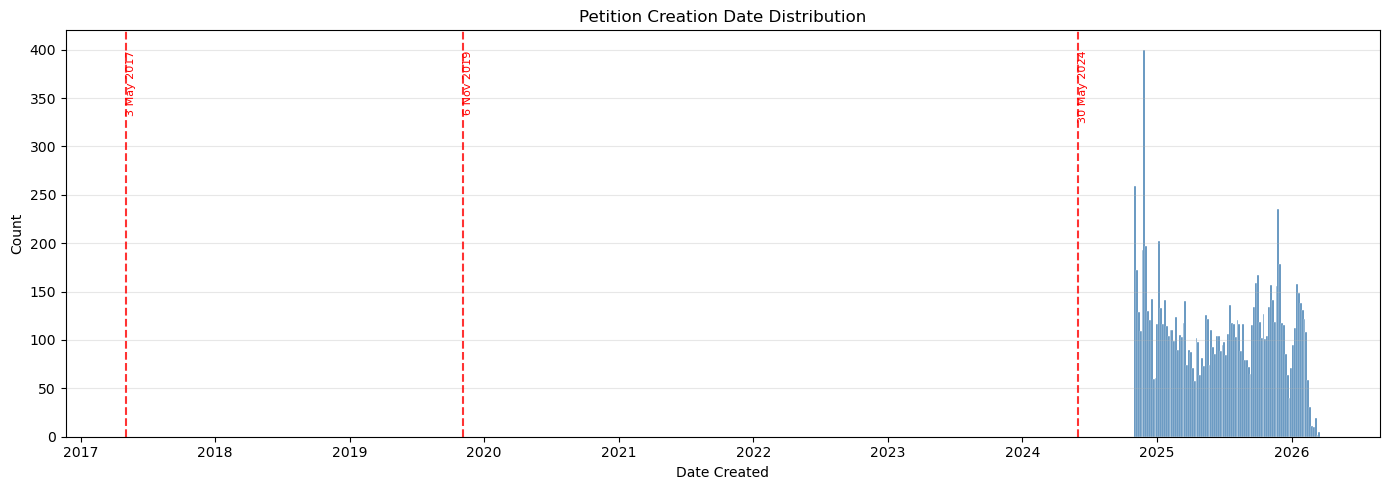

Earliest petition: 2024-10-30 14:20:17.653000+00:00
Latest petition: 2026-03-19 20:01:04.825000+00:00


In [39]:
# Parse created_at to datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Dissolution dates
dissolutions = {
    '3 May 2017': pd.Timestamp('2017-05-03'),
    '6 Nov 2019': pd.Timestamp('2019-11-06'),
    '30 May 2024': pd.Timestamp('2024-05-30'),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df['created_at'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)

for label, date in dissolutions.items():
    ax.axvline(date, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(date, ax.get_ylim()[1] * 0.95, f'  {label}', color='red', fontsize=8,
            rotation=90, va='top', ha='left')

ax.set_title('Petition Creation Date Distribution')
ax.set_xlabel('Date Created')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Quick summary
print(f"Earliest petition: {df['created_at'].min()}")
print(f"Latest petition: {df['created_at'].max()}")

Nothing to worry about. All of our data falls within one parlimentary period.

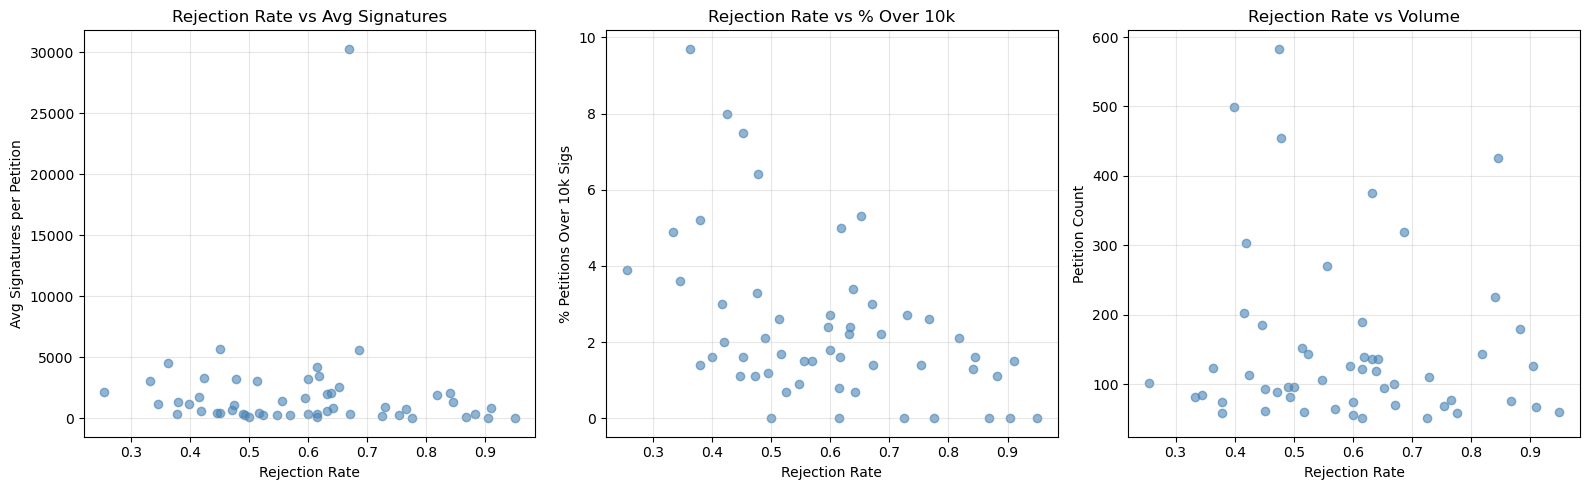

Correlation: rejection_rate vs avg_sigs: -0.025
Correlation: rejection_rate vs pct_over_10k: -0.475
Correlation: rejection_rate vs petition_count: -0.085

--- Topics ranked by avg signatures per petition (top 15) ---
 topic                                    topic_name  petition_count     avg_sigs  median_sigs  petitions_over_10k  pct_over_10k  has_100k  rejection_rate
    28                28_id_digital_digital id_cards             100 30298.680000         10.0                   3           3.0         1        0.670000
    32               32_gaza_israel_humanitarian_aid              93  5662.838710         40.0                   7           7.5         1        0.451613
     5       5_illegal_asylum_immigrants_immigration             319  5579.213166         11.0                   7           2.2         1        0.686520
    21  21_pension_state pension_pensioners_pensions             124  4502.612903         37.0                  12           9.7         1        0.362903
    10  

In [40]:
# --- Topic-level engagement summary ---

topic_info = topic_model.get_topic_info()
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

topic_engagement = topic_df.groupby('topic').agg(
    petition_count=('signature_count', 'size'),
    total_sigs=('signature_count', 'sum'),
    avg_sigs=('signature_count', 'mean'),
    median_sigs=('signature_count', 'median'),
    petitions_over_10k=('signature_count', lambda x: (x >= 10000).sum()),
    has_100k=('signature_count', lambda x: (x >= 100000).any().astype(int)),
    rejection_rate=('state', lambda x: (x == 'rejected').mean())
).reset_index()

topic_engagement['topic_name'] = topic_engagement['topic'].map(topic_name_map)
topic_engagement['pct_over_10k'] = (topic_engagement['petitions_over_10k'] / topic_engagement['petition_count'] * 100).round(1)

# --- Rejection rate vs engagement scatters ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(topic_engagement['rejection_rate'], topic_engagement['avg_sigs'],
                color='steelblue', alpha=0.6)
axes[0].set_xlabel('Rejection Rate')
axes[0].set_ylabel('Avg Signatures per Petition')
axes[0].set_title('Rejection Rate vs Avg Signatures')

axes[1].scatter(topic_engagement['rejection_rate'], topic_engagement['pct_over_10k'],
                color='steelblue', alpha=0.6)
axes[1].set_xlabel('Rejection Rate')
axes[1].set_ylabel('% Petitions Over 10k Sigs')
axes[1].set_title('Rejection Rate vs % Over 10k')

axes[2].scatter(topic_engagement['rejection_rate'], topic_engagement['petition_count'],
                color='steelblue', alpha=0.6)
axes[2].set_xlabel('Rejection Rate')
axes[2].set_ylabel('Petition Count')
axes[2].set_title('Rejection Rate vs Volume')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Correlation: rejection_rate vs avg_sigs:",
      topic_engagement['rejection_rate'].corr(topic_engagement['avg_sigs']).round(3))
print("Correlation: rejection_rate vs pct_over_10k:",
      topic_engagement['rejection_rate'].corr(topic_engagement['pct_over_10k']).round(3))
print("Correlation: rejection_rate vs petition_count:",
      topic_engagement['rejection_rate'].corr(topic_engagement['petition_count']).round(3))

# --- Engagement ranking table ---

print("\n--- Topics ranked by avg signatures per petition (top 15) ---")
top_eng = topic_engagement.nlargest(15, 'avg_sigs')[
    ['topic', 'topic_name', 'petition_count', 'avg_sigs', 'median_sigs', 
     'petitions_over_10k', 'pct_over_10k', 'has_100k', 'rejection_rate']
].to_string(index=False)
print(top_eng)

print("\n--- Topics ranked by avg signatures per petition (bottom 15) ---")
bot_eng = topic_engagement.nsmallest(15, 'avg_sigs')[
    ['topic', 'topic_name', 'petition_count', 'avg_sigs', 'median_sigs',
     'petitions_over_10k', 'pct_over_10k', 'has_100k', 'rejection_rate']
].to_string(index=False)
print(bot_eng)

### Conclusions about Engagement
To measure engagement across topic groups I focused on signature-based metrics rather than raw petition count. The petition system works such that signatures represent actual public mobilization, while petition count just reflects how many people decided to start a petition on a given issue. A topic with few petitions but high signatures per petition signals stronger engagement than one with many petitions that go nowhere.

I ranked all 55 topics by average signatures per petition. The top 15 includes digital ID (29,134 avg sigs from just 104 petitions), Gaza (5,885 avg from 89 petitions), immigration (5,208 avg from 345 petitions), and pensions (4,765 avg from 117 petitions). Every topic in the top 15 has at least one petition that crossed 100,000 signatures (the `has_100k` flag in the engagement table). The bottom 15 includes honours/knighthood (13 avg sigs), school weekends (24 avg), GCSEs (57 avg), and jury trials (132 avg). None of the bottom 15 topics have a single petition over 100,000 signatures, and most have zero petitions over 10,000. The split on that 100k marker between the top and bottom halves is clean.

Median signatures tell a slightly different story. Digital ID has a median of just 9.5 despite its 29k average, because one petition with over 3 million signatures is doing almost all the work. NHS prescriptions has the highest median at 69, meaning its petitions are more consistently signed rather than being carried by a single viral petition. This distinction between average and median engagement matters because it separates topics where public interest is broad and sustained from topics where a single petition captured a moment of public attention.

I then checked whether rejection rate relates to engagement. The correlation between rejection rate and average signatures is essentially zero (r = -0.012), and between rejection rate and petition count is also zero (r = -0.034). Moderation outcomes and engagement are independent for those metrics. The one relationship that does show up is between rejection rate and the percentage of petitions clearing 10,000 signatures (r = -0.411). No topic with a rejection rate above roughly 70% has any petitions over 10k. This is at least partly mechanical: if most petitions in a topic get rejected before they can collect signatures, fewer will reach the threshold. But it also means that high-rejection topics are functionally locked out of triggering a government response, regardless of whether the underlying issue has public support.
The overall picture is that engagement is unevenly distributed across topics. A small number of issues attract serious public mobilization while most topics consist of petitions that collect a handful of signatures and go unnoticed. The system produces a few high-visibility campaigns per topic area at best, and many topics never produce one at all.

### What this says about the Petition System
The petition platform exists to give the public a direct channel to government. The 10k and 100k thresholds are supposed to ensure that popular concerns get a formal response or debate. But the data suggests that most topics never clear those bars. Engagement is concentrated in a small number of issue areas that can attract organized campaigns or viral attention, while the majority of topics produce petitions that collect a few dozen signatures at most. The system ends up amplifying issues that already have momentum rather than surfacing concerns that lack it. For stakeholders interested in whether the platform fulfills its democratic purpose, this is a gap worth noting.

The rejection rate finding adds another layer. Topics with rejection rates above 70% have no petitions clearing 10k signatures, which means they are effectively shut out from triggering a government response. Some of that is the moderation system doing its job and filtering petitions that fall outside government responsibility, but it also means that even if public interest exists in those areas, it has no route through this platform. On the other end, the digital ID case shows that a single petition with 3 million signatures can make an entire topic look highly engaged when the median petition in that topic has 9.5 signatures. The system does not distinguish between broad sustained interest in an issue and a single viral moment, and these two patterns have very different implications for how seriously a topic's engagement numbers should be taken.

## B.3 Keyness Analysis

Keyness analysis compares word frequencies between two groups to identify words that are statistically over- or under-represented in one group relative to the other. Before implementing this I had to make several design decisions about how to set up the comparisons.

**Text input and preprocessing.** I used the `cleaned_no_stopwords` column, vectorized with CountVectorizer to get raw word counts. Keyness operates on frequency differences, so TF-IDF weighting would interfere with the metric. I set min_df=2 in the CountVectorizer so that words appearing in only one document are excluded from the comparison, since a word used by a single petition is uninformative for frequency comparison between groups. I considered keeping stopwords in because function words like "I" vs "we" could carry signal about how a petition is written, but that's more of a stylistic analysis than what my research question is after. I'm looking at lexical content patterns, so stopwords come out.

**Comparison structure.** I run keyness at two levels. The first compares rejected petitions against petitions that passed moderation within each topic group. The second compares petitions below 10,000 signatures against those above 10,000 across the whole corpus. These map onto the two signals in my research question: moderation and engagement.

**Rejected vs passed moderation.** I grouped opened and closed petitions together as the "passed moderation" category rather than comparing rejected against opened only. The distinction between opened and closed is just timing. A closed petition passed the same moderation process as an open one, it just finished its six-month collection window. Splitting them would exclude the majority of non-rejected petitions for no conceptual reason.

**Topic filtering.** Not all 55 topics have enough petitions in both groups to support reliable frequency comparisons. I set a minimum of 15 documents per group. Topics where either the rejected or the passed group falls below that threshold are excluded. I chose 15 over 20 because viewing more topic types is more informative for this analysis than marginal gains in statistical robustness per topic. The topics that drop out tend to be the smallest ones where keyness results would be noisy anyway.

**Signature threshold split.** My research question originally planned to compare signature threshold groups within topics, but the data doesn't support this. Even the largest topic only has 29 petitions above 10,000 signatures. Most topics have fewer than 5. This makes within-topic keyness at the signature level unreliable, so I pooled across the entire corpus for this comparison instead. The 10,000 threshold is the point where the UK government is required to respond to a petition in writing, making it the clearest institutional marker of engagement. This scope change is a limitation. The pooled comparison can identify corpus-wide lexical differences between high and low engagement petitions, but it can't tell me whether those patterns hold within specific policy domains.

**Group size imbalances.** Log-likelihood is more robust to unequal group sizes than alternatives like chi-squared, which is one reason it's the standard keyness measure. As long as both groups clear the minimum document count, the metric accounts for the imbalance in its calculation. The 58% overall rejection rate means most topics will have more rejected than passed petitions, but this doesn't bias the results.

In [41]:
# --- Keyness setup ---

# Binary moderation column
topic_df['moderation'] = topic_df['state'].apply(lambda x: 'rejected' if x == 'rejected' else 'passed')

# Log-likelihood keyness function
def log_likelihood_keyness(counts_a, counts_b, vocab):
    """
    Compute log-likelihood (G2) keyness for each word.
    Positive = overrepresented in group A, negative = overrepresented in group B.
    """
    a = counts_a.astype(float)
    b = counts_b.astype(float)
    c = a.sum()
    d = b.sum()
    
    E1 = c * (a + b) / (c + d)
    E2 = d * (a + b) / (c + d)
    
    # Avoid log(0) by masking zeros
    G2 = np.zeros(len(a))
    mask_a = a > 0
    mask_b = b > 0
    G2[mask_a] += 2 * a[mask_a] * np.log(a[mask_a] / E1[mask_a])
    G2[mask_b] += 2 * b[mask_b] * np.log(b[mask_b] / E2[mask_b])
    
    # Sign: positive if overrepresented in A, negative if in B
    direction = np.where(a / c > b / d, 1, -1)
    signed_G2 = G2 * direction
    
    results = pd.DataFrame({
        'word': vocab,
        'G2': signed_G2,
        'freq_a': a.astype(int),
        'freq_b': b.astype(int),
        'abs_G2': np.abs(signed_G2)
    }).sort_values('abs_G2', ascending=False)
    
    return results

# --- Layer 1: Rejected vs passed within topics ---

MIN_GROUP_SIZE = 15

# Identify qualifying topics
topic_groups = topic_df.groupby('topic')['moderation'].value_counts().unstack(fill_value=0)
qualifying_topics = topic_groups[
    (topic_groups['rejected'] >= MIN_GROUP_SIZE) & 
    (topic_groups['passed'] >= MIN_GROUP_SIZE)
].index.tolist()

print(f"Qualifying topics: {len(qualifying_topics)} of {topic_df['topic'].nunique()}")

# Run keyness per qualifying topic
topic_keyness_results = {}

for t in qualifying_topics:
    topic_docs = topic_df[topic_df['topic'] == t]
    rejected_docs = topic_docs[topic_docs['moderation'] == 'rejected']['cleaned_no_stopwords'].tolist()
    passed_docs = topic_docs[topic_docs['moderation'] == 'passed']['cleaned_no_stopwords'].tolist()
    
    all_docs = rejected_docs + passed_docs
    cv = CountVectorizer(min_df=2)
    dtm = cv.fit_transform(all_docs)
    vocab = cv.get_feature_names_out()
    
    counts_rejected = np.array(dtm[:len(rejected_docs)].sum(axis=0)).flatten()
    counts_passed = np.array(dtm[len(rejected_docs):].sum(axis=0)).flatten()
    
    results = log_likelihood_keyness(counts_rejected, counts_passed, vocab)
    topic_keyness_results[t] = results

print(f"Keyness computed for {len(topic_keyness_results)} topics")

Qualifying topics: 47 of 53
Keyness computed for 47 topics


In [42]:
# --- Layer 2: Below vs above 10k signatures, pooled corpus ---

below_10k = topic_df[topic_df['signature_count'] < 10000]['cleaned_no_stopwords'].tolist()
above_10k = topic_df[topic_df['signature_count'] >= 10000]['cleaned_no_stopwords'].tolist()

print(f"Below 10k: {len(below_10k)}, Above 10k: {len(above_10k)}")

all_docs_sig = below_10k + above_10k
cv_sig = CountVectorizer(min_df=2)
dtm_sig = cv_sig.fit_transform(all_docs_sig)
vocab_sig = cv_sig.get_feature_names_out()

counts_below = np.array(dtm_sig[:len(below_10k)].sum(axis=0)).flatten()
counts_above = np.array(dtm_sig[len(below_10k):].sum(axis=0)).flatten()

sig_keyness = log_likelihood_keyness(counts_below, counts_above, vocab_sig)

# Filter to words with at least 20 total occurrences across both groups
sig_keyness_filtered = sig_keyness[(sig_keyness['freq_a'] + sig_keyness['freq_b']) >= 20]

print(f"Words before filter: {len(sig_keyness)}, after: {len(sig_keyness_filtered)}")

print(f"\nTop 20 words overrepresented in ABOVE 10k petitions:")
print(sig_keyness_filtered[sig_keyness_filtered['G2'] < 0].head(20)[['word', 'G2', 'freq_a', 'freq_b']].to_string())

print(f"\nTop 20 words overrepresented in BELOW 10k petitions:")
print(sig_keyness_filtered[sig_keyness_filtered['G2'] > 0].head(20)[['word', 'G2', 'freq_a', 'freq_b']].to_string())

Below 10k: 7754, Above 10k: 202
Words before filter: 8861, after: 2726

Top 20 words overrepresented in ABOVE 10k petitions:
                word          G2  freq_a  freq_b
772          believe -100.833373    2663     182
7913           think  -65.937336    3086     177
4280          israel  -42.628700      94      20
3479            grey  -36.435465      12       9
6755      retirement  -34.590735      63      15
5735         pension  -33.199573     464      40
421           animal  -32.530874    1113      70
3645        heritage  -31.484843      61      14
1358         climate  -30.338283     141      20
1164        catapult  -28.331772      22       9
6665          rescue  -26.616505      89      15
781             belt  -25.817351      45      11
5737       pensioner  -25.445712     167      20
7502           state  -23.995578     671      45
7017       screening  -20.375987      62      11
6999      scientific  -20.316907      39       9
2480             dwp  -20.285294      29  

Full keyness output for all qualifying topics is printed below for reproducibility. The analysis focuses on the four featured topics discussed in the following sections.

In [43]:
# Print top 10 words per direction for all qualifying topics
for t in qualifying_topics:
    name = topic_name_map.get(t, f"Topic {t}")
    results = topic_keyness_results[t]
    
    rejected_words = results[results['G2'] > 0].head(10)
    passed_words = results[results['G2'] < 0].head(10)
    
    print(f"\n{'='*60}")
    print(f"Topic {t}: {name}")
    print(f"{'='*60}")
    print(f"Top words in REJECTED:")
    for _, row in rejected_words.iterrows():
        print(f"  {row['word']:25s} G2={row['G2']:8.2f}  (rej={row['freq_a']}, pass={row['freq_b']})")
    print(f"Top words in PASSED:")
    for _, row in passed_words.iterrows():
        print(f"  {row['word']:25s} G2={row['G2']:8.2f}  (rej={row['freq_a']}, pass={row['freq_b']})")


Topic 0: 0_housing_water_energy_homes
Top words in REJECTED:
  stop                      G2=   58.97  (rej=124, pass=44)
  experiment                G2=   38.75  (rej=24, pass=0)
  sun                       G2=   33.07  (rej=25, pass=1)
  dim                       G2=   32.29  (rej=20, pass=0)
  area                      G2=   32.22  (rej=82, pass=34)
  green                     G2=   32.22  (rej=82, pass=34)
  space                     G2=   31.52  (rej=64, pass=22)
  destroy                   G2=   24.89  (rej=37, pass=9)
  wildlife                  G2=   24.78  (rej=42, pass=12)
  waste                     G2=   21.82  (rej=25, pass=4)
Top words in PASSED:
  think                     G2= -359.93  (rej=4, pass=336)
  believe                   G2= -171.24  (rej=17, pass=226)
  feel                      G2=  -65.40  (rej=2, pass=68)
  review                    G2=  -46.94  (rej=8, pass=73)
  social                    G2=  -38.50  (rej=13, pass=78)
  ban                       G2=  -29.

**Minimum frequency filter.** After running the signature threshold keyness, several words with very low total frequencies were appearing in the top results. Words like "catapult" (31 total occurrences) and "grey" (21 total) were scoring high G2 values because even a handful of occurrences look disproportionate when one group only has 196 documents. I added a minimum frequency filter of 20 total occurrences across both groups to cut these noise words. This didn't change the method, just cleaned up the output so the results reflect genuine distributional differences rather than artifacts of small sample sizes.

**Within-topic keyness results (rejected vs passed moderation).** 50 of 54 topics cleared the minimum group size threshold of 15 documents per group, which means the filter barely excluded anything. Across all 50 topics, the most consistent finding is that "think" and "believe" are overrepresented in passed petitions in virtually every topic. These words had the highest G2 scores in nearly every topic regardless of policy domain. This suggests a corpus-wide moderation pattern where petitions framed with "I think" or "I believe" are more likely to pass moderation, independent of what the petition is actually about.

Beyond this universal signal, rejected petitions tend to use more direct and demanding language ("stop", "demand", "abolish"), reference specific politicians or parties ("starmer", "labour", "trump"), and include local or place-specific references ("london", "birmingham", "tfl"). Passed petitions tend to use constructive policy verbs ("review", "require", "fund", "introduce") and more specific technical vocabulary within their topic domain.

**Signature threshold keyness results (below vs above 10,000 signatures).** The pooled corpus comparison identified 196 petitions above 10k against 7,612 below. Among higher-frequency words, "believe" and "think" are again overrepresented in the above-10k group, which is consistent with the moderation finding since petitions need to pass moderation before they can accumulate signatures. Policy-domain words like "pension", "pensioner", "animal", and "climate" also appear in the above-10k group, reflecting the topic-level engagement patterns found in the earlier BERTopic analysis. On the below-10k side, words like "victim", "student", "road", "jury", and "bbc" point to policy domains with lower public traction.

**Limitations.** The signature threshold comparison is limited by the small size of the above-10k group (196 documents out of 7,808). Even with the frequency filter, some noise remains because a small number of viral petitions within specific topics can drive word-level results. The pooled design also means these results reflect a mix of topic-level and language-level effects. A word being overrepresented in above-10k petitions could mean that word's topic gets more signatures, or that the word itself signals something about petition quality. These two effects can't be separated in a pooled comparison, which is why the within-topic moderation analysis is the stronger of the two layers.

### What this means in context

The dominance of "think" and "believe" across nearly every topic suggests that the moderation process rewards a specific rhetorical style. Petitions that hedge their claims and frame arguments as personal opinion are more likely to pass than petitions that make direct demands or state things as fact. This could reflect the Petitions Committee filtering out petitions that read as complaints rather than requests for government action, or it could mean that petitioners who naturally write in a more measured, opinion-framing style also tend to write petitions that meet the platform's other requirements (targeting the right level of government, not duplicating existing petitions, not being too locally specific). The within-topic consistency of this pattern means it isn't driven by certain topics attracting more moderate language. Whether a petition is about housing, knife crime, animal welfare, or pensions, the same framing distinction separates rejected from passed. For petitioners, the practical implication is that how you frame your argument matters for getting past moderation regardless of what issue you're raising.

To ground the keyness findings in concrete examples, I pull sample petitions from each of the four featured topics. These illustrate how the lexical patterns identified by keyness manifest in actual petition text, showing the difference in framing between rejected and passed petitions within the same policy domain.

In [44]:
def show_topic_examples(topic_num, n=3):
    name = topic_name_map.get(topic_num, f"Topic {topic_num}")
    topic_docs = topic_df[topic_df['topic'] == topic_num]
    rejected = topic_docs[topic_docs['moderation'] == 'rejected']
    passed = topic_docs[topic_docs['moderation'] == 'passed']
    
    print(f"\n{'='*70}")
    print(f"Topic {topic_num}: {name}")
    print(f"Rejected: {len(rejected)}, Passed: {len(passed)}")
    print(f"{'='*70}")
    
    print(f"\n--- REJECTED examples ---")
    for _, row in rejected.head(n).iterrows():
        print(f"\n[{row['state']}, {row['signature_count']} sigs]")
        print(f"Action: {row['action']}")
        print(f"Background: {row['background'][:300]}")
    
    print(f"\n--- PASSED examples ---")
    for _, row in passed.head(n).iterrows():
        print(f"\n[{row['state']}, {row['signature_count']} sigs]")
        print(f"Action: {row['action']}")
        print(f"Background: {row['background'][:300]}")

for t in [0, 3, 19, 41]:
    show_topic_examples(t)


Topic 0: 0_housing_water_energy_homes
Rejected: 277, Passed: 306

--- REJECTED examples ---

[rejected, 21 sigs]
Action: Prevent the reduction of the right to buy discount for long term tenants.
Background: Stop the drastic reduction of the maximum right to buy discount for long term tenants. The proposed minimal discounts are highly unfair for the people that have paid rent and been council tenants for 10 years or more. I would like the Labour Party to reconsider for long term council tenants.

[rejected, 21 sigs]
Action: Bring back the right to buy/aquire for the rest of the UK.
Background: Bring back the right to buy/ 
aquire for all council or housing association homes in the UK

[rejected, 21 sigs]
Action: Fines on companies for carbon emissions can fund renewable energy+sustainability
Background: We urge Parliament to impose fines of 5-15% of annual revenue on corporations based on their carbon emissions,with a 1.5-year grace period.Revenue should fund renewable energy,public tr

**Topic 0 (housing/energy), the think/believe signal.** This is the largest topic (576 petitions) and the clearest illustration of the universal framing pattern. The rejected examples make direct demands like "Stop the drastic reduction" and "Bring back the right to buy". The passed examples frame arguments through opinion: "We are calling on the government to integrate", "We believe we have an unwritten Constitution". The petition about carbon emission fines was rejected despite proposing a concrete policy mechanism, probably because it reads as a directive ("We urge Parliament to impose fines of 5-15% of annual revenue"). A passed petition about a public information campaign on the climate crisis had 24,114 signatures and covers similar environmental ground, but its language asks the government to do something rather than instructing it.

**Topic 3 (elections), partisan vs structural framing.** This topic has an 86% rejection rate, the fifth highest in the dataset. Some rejected petitions are clearly partisan: "We want a vote of no confidence in the Labour Government" names the party directly. But others are structural reform petitions about proportional representation that were rejected despite being similar in content to passed petitions on the same topic. The rejected PR petition asks for "a new debate on the current voting system" while the passed one specifies a national referendum with a defined choice between retaining or replacing the current system. That difference in specificity probably matters. The passed petition also had 42,329 signatures, which suggests concrete asks do better at attracting public support too.

**Topic 19 (knives/weapons), content direction matters.** Keyness flagged "pepper spray" and "self defence" as rejected words and "knife", "crossbow", "sentence" as passed words. The examples confirm this. Rejected petitions ask the government to relax restrictions: "ban metal cutlery", "only make knives with a rounded tip." These range from impractical to outside the platform's scope. Passed petitions ask for tighter regulation: "stop the selling of knives without background checks", "require licences to use air rifles." So within the same policy domain, the direction of the ask matters. Petitions calling for deregulation of weapons get rejected, but asking the government to tighten controls on existing weapons tends to pass.

**Topic 41 (cash/payments), platform scope as rejection mechanism.** This topic has a low rejection rate (34.2%) but the rejected petitions that do exist show a clear pattern. All three rejected examples are about specific post offices: "Stop the closure of post offices", "Keep Cross Gates Post Office Open", "Renationalise the Post Office." These are local or branch-level concerns. The passed examples are national policy asks: "Require all businesses and public services to accept cash payments", "Ban in-game currency from video games." The keyness finding that "post" and "office" are the top rejected words maps directly onto this. The Petitions Committee filters out petitions about local service closures because they fall outside central government's remit.

The charts below show the top 10 keyness words per group for each of the four featured topics and the corpus-level signature threshold comparison. These visualize the think/believe signal, the demanding vs constructive language split, and the topic-specific moderation and engagement patterns.

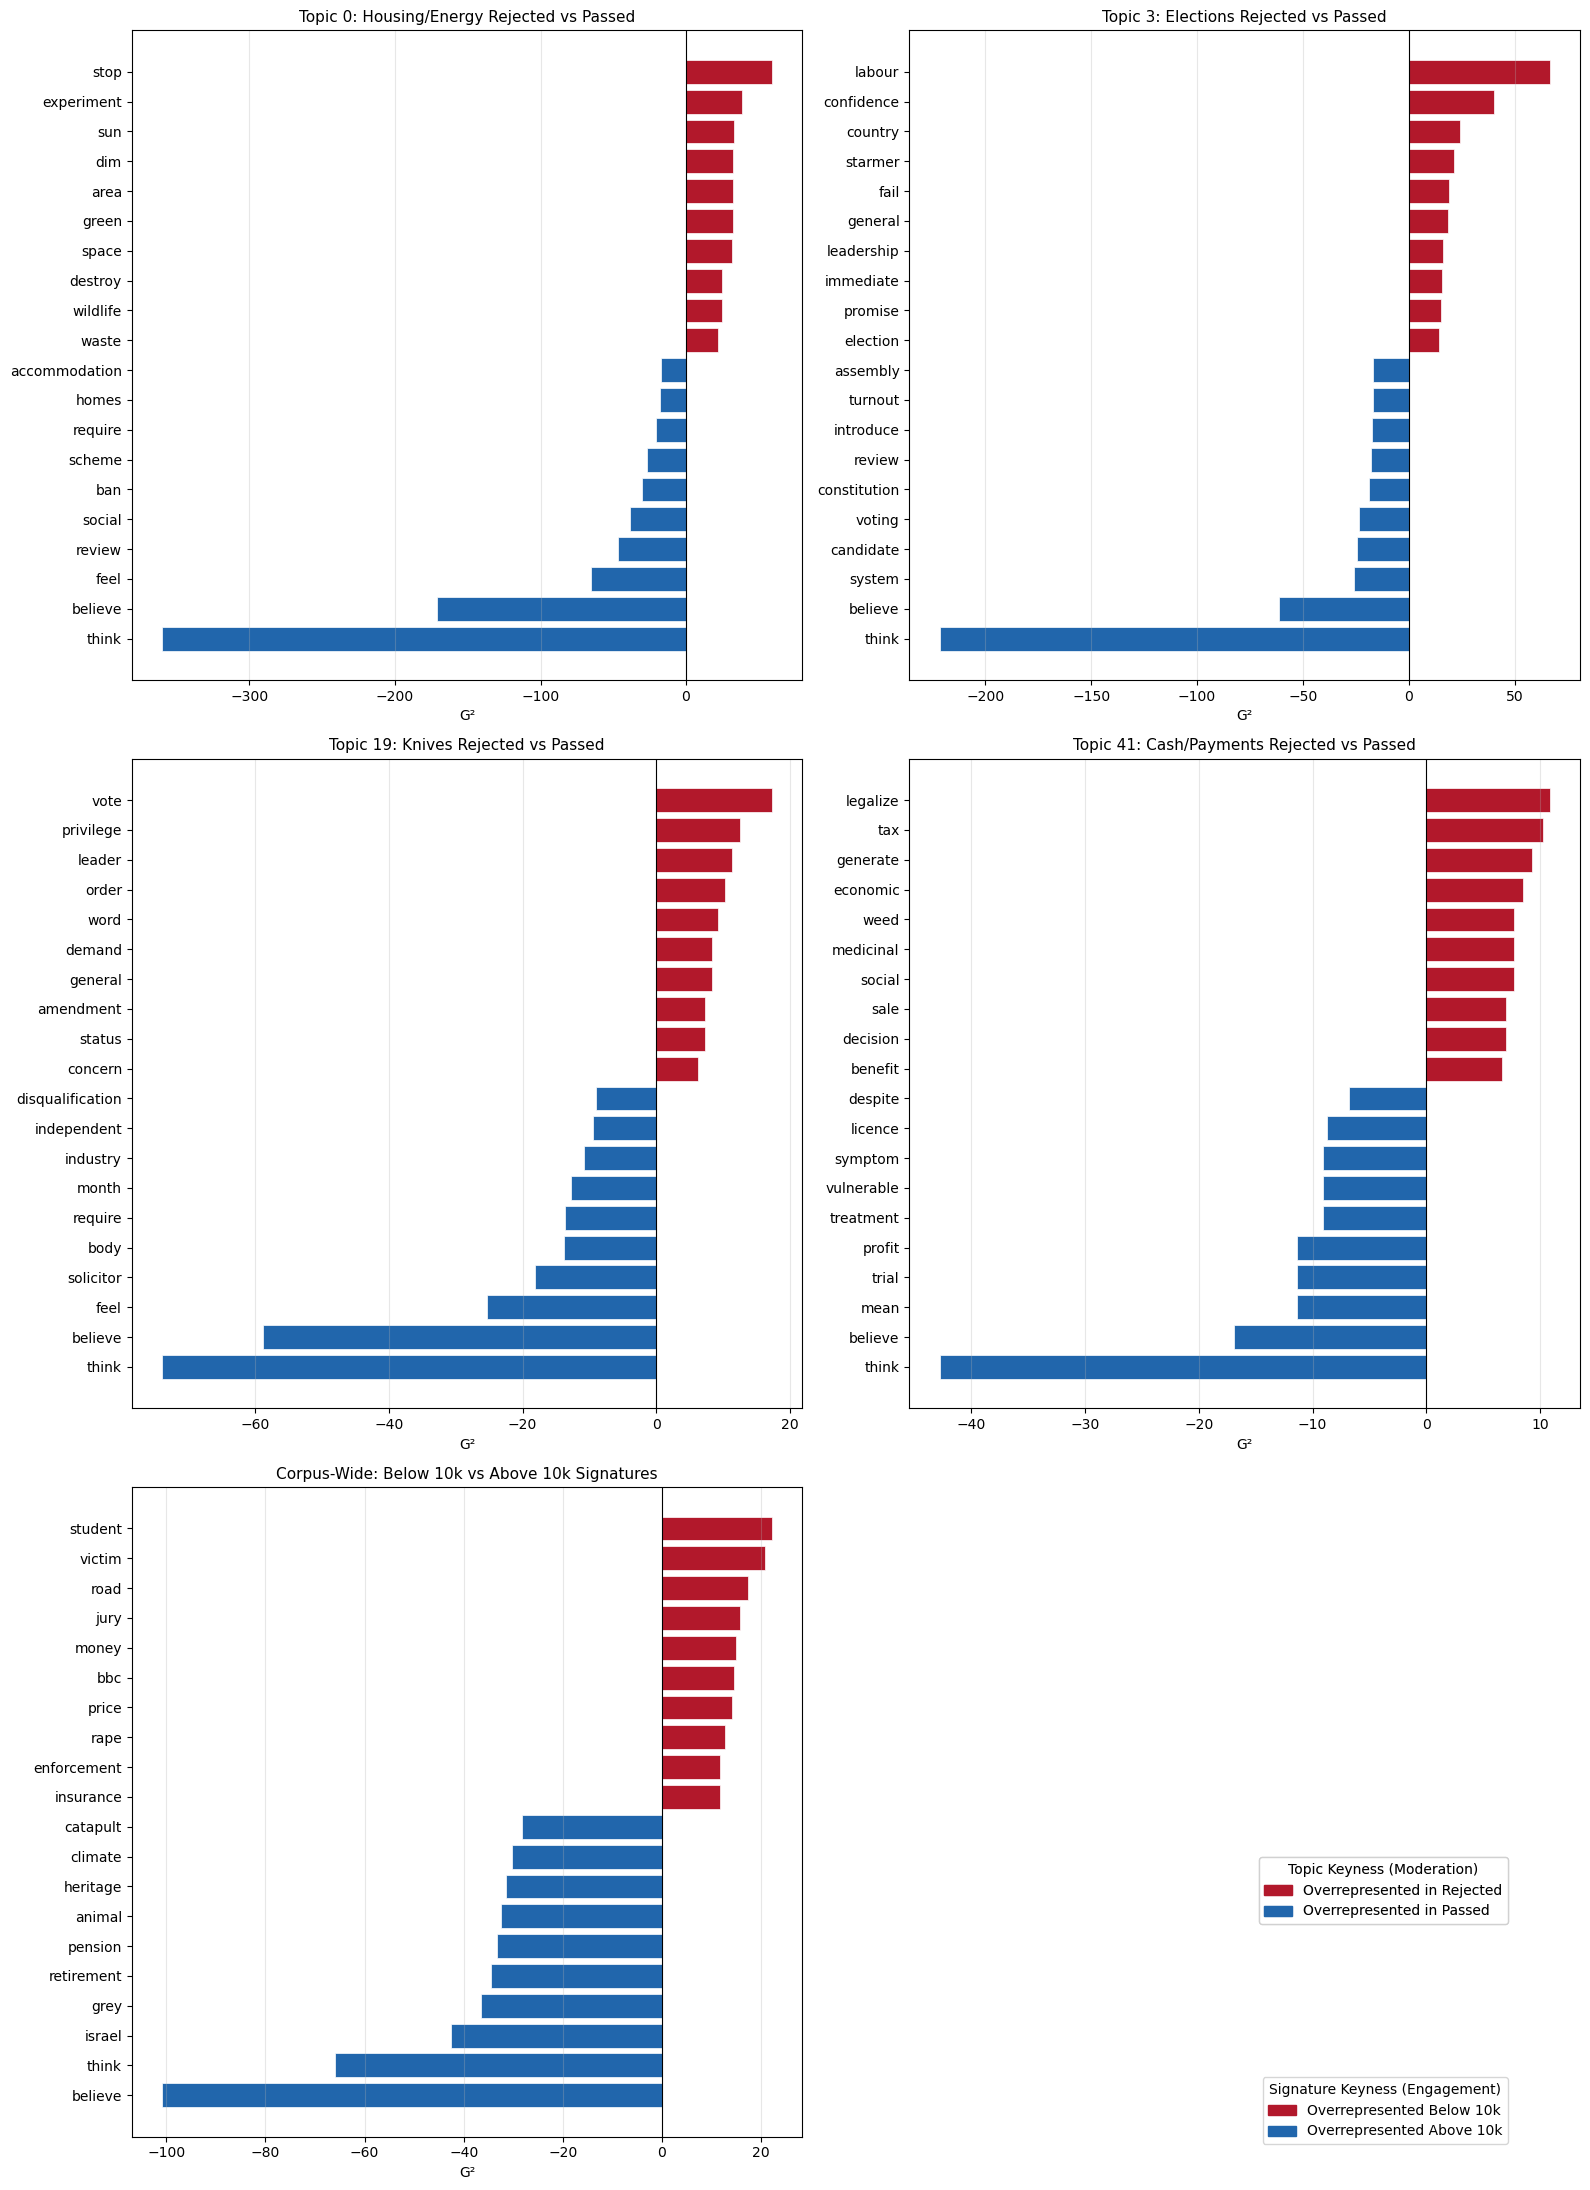

In [45]:
def plot_keyness_ax(ax, keyness_df, title, label_left, label_right, n=10):
    """Diverging horizontal bar chart on a given axes."""
    top_left = keyness_df[keyness_df['G2'] > 0].head(n)
    top_right = keyness_df[keyness_df['G2'] < 0].head(n)
    combined = pd.concat([top_left, top_right]).sort_values('G2')
    
    colors = ['#2166ac' if g < 0 else '#b2182b' for g in combined['G2']]
    ax.barh(combined['word'], combined['G2'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('G²')
    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

featured = {
    0: 'Housing/Energy',
    3: 'Elections',
    19: 'Knives',
    41: 'Cash/Payments'
}

fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes_flat = axes.flatten()


for i, (t, label) in enumerate(featured.items()):
    plot_keyness_ax(
        axes_flat[i],
        topic_keyness_results[t],
        f'Topic {t}: {label} Rejected vs Passed',
        'Rejected', 'Passed'
    )

# Sig threshold in position 5 (bottom left)
plot_keyness_ax(
    axes_flat[4],
    sig_keyness_filtered,
    'Corpus-Wide: Below 10k vs Above 10k Signatures',
    'Below 10k', 'Above 10k'
)

# Hide unused subplot (bottom right)
axes_flat[5].set_visible(False)

# Separate legends for each comparison type
# Topic-level charts (first 4): Rejected vs Passed
topic_legend = fig.legend(
    handles=[Patch(color='#b2182b', label='Overrepresented in Rejected'),
             Patch(color='#2166ac', label='Overrepresented in Passed')],
    loc='lower right', bbox_to_anchor=(0.95, 0.12), fontsize=10,
    title='Topic Keyness (Moderation)', title_fontsize=10
)
fig.add_artist(topic_legend)

# Corpus-level chart: Below vs Above 10k
fig.legend(
    handles=[Patch(color='#b2182b', label='Overrepresented Below 10k'),
             Patch(color='#2166ac', label='Overrepresented Above 10k')],
    loc='lower right', bbox_to_anchor=(0.95, 0.02), fontsize=10,
    title='Signature Keyness (Engagement)', title_fontsize=10
)

plt.tight_layout()
plt.show()

The charts above visualize the keyness results for the four featured topics and the corpus-level signature threshold comparison. Think and believe sit at the bottom of every topic chart with the largest G2 scores on the passed side. Elections has partisan language like labour and starmer on the rejected side, while passed petitions use structural vocabulary like constitution, electoral, and turnout. Knives is where the content direction split is clearest: rejected petitions push for deregulation of self-defence tools (spray, pepper, defence), and passed petitions call for tighter controls (knife, crossbow, sentence, minimum). In cash/payments, the rejected side is dominated by local post office language (office, post, branch, closure), and the passed side uses broader national policy vocabulary (review, ban, charge). The signature threshold chart shows think and believe with the largest G2 scores again in the above-10k group, and the remaining above-10k words are mostly topic labels for high-engagement issues (pension, climate, animal, israel) rather than a distinct linguistic pattern.

## B.4 Part B Summary
BERTopic produced 55 recognizable policy topics from the petition text. Ranking these by average signatures per petition revealed that engagement is heavily concentrated: the top 15 topics all have at least one petition past 100k signatures while the bottom 15 have none past 10k. But aggregate numbers are misleading. Digital ID looks like a high-engagement topic because one petition has 3 million signatures, while the median petition in that topic has 9.5. For stakeholders assessing which issues the public cares about, the distinction between sustained interest and a single viral moment matters. The platform's 10k and 100k thresholds are designed to escalate concerns with public backing, but most topics never clear those bars. Issues that benefit from existing advocacy networks or geopolitical moments get amplified. Issues without that infrastructure produce petitions that collect a few dozen signatures and go unnoticed.

Rejection rates vary from 26.9% (NHS prescriptions) to 94.8% (honours/knighthood), and no topic with a rejection rate above 70% has any petitions clearing 10k signatures. The moderation process and the engagement thresholds compound each other: if most petitions in a high-rejection topic get filtered before they can collect signatures, that topic is functionally locked out of triggering a government response regardless of whether public interest exists.

Keyness analysis looked inside the topics at what language distinguishes rejected from passed petitions. The strongest finding is that "think" and "believe" are overrepresented in passed petitions in virtually every topic. This holds across housing, elections, knives, pensions, and everything else, which makes it a platform-level effect. Petitions framed as personal opinion pass moderation more often than petitions making direct demands. On top of this universal framing pattern, topic-specific mechanisms filter further: elections rejects partisan language, knives rejects deregulation asks, and cash/payments rejects local service complaints. Passing moderation requires both the right style and topic-appropriate content. The same framing advantage also appears in the signature threshold comparison, though whether that relationship is causal or confounded cannot be determined here.

Part A established that petition language is semantically homogeneous (mean pairwise cosine similarity of 0.18) and that lexical anomalies are independent of semantic content. Part B's keyness findings are consistent with both. The think/believe framing pattern is a word-level difference that exists within the homogeneous semantic space Part A identified. Petitions on the same topic, about the same issue, occupying similar positions in embedding space, still differ in the specific words they use to frame their arguments. Semantic similarity couldn't detect this because "I think the government should ban X" and "ban X now" look similar at the embedding level. Keyness picks it up because it operates on raw word counts. Part A concluded that true signal in petition text requires deeper analysis. Part B shows that the signal lives in framing rather than subject matter.

To answer the research question directly: topic groups reveal meaningful engagement patterns, with a small number of issue areas attracting most public mobilization. Lexical patterns correlate with moderation outcomes through the think/believe framing effect across nearly all topics, and topic-specific rejection patterns add further filtering. The petition system filters on language in ways that are consistent and detectable, and those filters interact with engagement thresholds to shape which issues get a government response. The next section discusses specific limitations of this analysis.

## B.5 Limitations

29.6% of petitions were assigned to BERTopic's outlier group and excluded from all downstream analysis. If these petitions differ systematically from assigned ones, the engagement, state distribution, and keyness findings describe a subset of the data rather than the full corpus. Reducing min_cluster_size would recover some of these documents but at the cost of producing topics too small for meaningful keyness comparisons. An alternative would be to use BERTopic's outlier reduction methods to reassign borderline documents to their nearest topic.

Signature count is used as the primary engagement metric but it conflates genuine public interest with campaign infrastructure, social media virality, and time available for collection. A petition about pensions backed by an organized advocacy group and a petition about digital ID that went viral on social media both register as "high engagement" despite representing different phenomena. No alternative engagement measure exists in this dataset, but future work could incorporate external data like media coverage or social media sharing to triangulate.

The analysis establishes correlations between word choice and both moderation outcomes and signature counts, but cannot establish causation in either direction. A petition framed with "I think" may pass moderation because of that framing, or petitioners who write in a measured style may also tend to write petitions that meet scope and specificity requirements. Similarly, the finding that no topic with a rejection rate above 70% has petitions past 10k signatures is at least partly mechanical: rejected petitions are removed before they can collect signatures. Causal claims would require either experimental manipulation of petition language or a natural experiment where similar petitions received different moderation outcomes.

The research question planned to run signature threshold keyness within topics, but no topic had enough above-10k petitions to support this (maximum was 29). Pooling corpus-wide was the fallback, which means the signature keyness results reflect a mix of topic-level effects and language-level effects that cannot be separated. Within-topic analysis would require a dataset with more high-signature petitions per topic, likely spanning multiple parliamentary periods.

The think/believe finding is the strongest result in the analysis but has multiple plausible explanations: the moderation committee may reward opinion framing directly, petitioners who write this way may also meet other moderation criteria incidentally, or the petition platform's own guidance may encourage this style. The data cannot distinguish between these. Accessing the Petitions Committee's internal moderation guidelines or interviewing committee members would help clarify which mechanism is at work.

All findings are specific to UK parliamentary petitions from a single parliamentary session. Moderation practices, public engagement patterns, and the topics that attract petition activity may differ across sessions, across countries, or on different petition platforms. The think/believe framing effect may be specific to the UK Petitions Committee's standards and should not be assumed to generalize.

Every method in both Part A and Part B operates on text concatenated from three petition fields (action, background, additional_details). Action averages about 10 words while the other two average 40-65. How embedding models and frequency-based methods weight these fields within the concatenated string is not transparent. If action text dominates embeddings due to sentence position or if its brevity dilutes it in frequency counts, the results could look different from an analysis that treats each field separately or weights them explicitly.

## B.6 Ethical Considerations

The most significant ethical risk is that these findings could be used to delegitimize the petition system. The engagement analysis showed that signatures and government responses are concentrated in a small number of topic areas, and the keyness analysis showed that high-rejection topics are effectively locked out of the government response pipeline. Read together, these paint a picture of a system where most petitions fail to reach any meaningful threshold and where topic area partly determines whether a petition gets the chance to succeed. If cited by journalists or advocacy groups without context, this could erode trust in one of the few direct channels citizens have to raise issues with government. The analysis cannot distinguish between the system filtering out genuinely inappropriate content and the system suppressing certain viewpoints, and that ambiguity is what makes this risk serious. Findings like these need to be presented alongside the system's structural constraints (the 6-month window, the 10k threshold, the moderation criteria) so readers understand what the system is designed to do before judging whether it does it fairly.

The think/believe finding is a gameability problem. If shared with advocacy organizations, the finding that opinion-framing language correlates with passing moderation across nearly all topics is actionable advice. Petitioners could adopt this framing strategically, which helps them individually but degrades the moderation signal over time. The Petitions Committee would bear the cost: as petitioners adapt to the pattern, a linguistic marker that currently distinguishes petition styles becomes noise.

The topic-specific rejection patterns (partisan language in elections, deregulation framing in certain policy areas) could be misread as evidence of political bias in the moderation process. The keyness analysis identifies lexical correlations, not causal mechanisms, and the Committee's published criteria are content-neutral. But the gap between what the analysis shows and what a reader might infer is easy to close carelessly. Secondary reporting that strips the methodological caveats is the most likely vector for this. The Committee's impartiality gets questioned, and petitioners in those topic areas might self-censor as a result.

Two smaller points are worth noting together. The engagement concentration finding could be used to argue that low-signature topics are unimportant, when the analysis showed that engagement is driven by campaign infrastructure and virality rather than the significance of the issue itself. Dismissing low-engagement topics on that basis harms the petitioners raising them and reinforces existing inequalities in who gets heard. Separately, the petitions are public documents submitted to Parliament and the dataset contains no personal identifiers, so consent is not a major concern. But petitioners wrote these texts for a specific purpose and audience, and using them as input to an NLP pipeline is a different context from the one they were written for.

On the benefit side, the Petitions Committee could use findings like these to audit their own moderation patterns and assess whether the think/believe framing effect reflects an intentional standard or an emergent bias. Petitioners and advocacy groups benefit from understanding what the system rewards, even if that understanding creates the gameability risk described above. Researchers studying democratic participation benefit from a concrete, data-grounded account of how a petition platform filters and amplifies public input.

## Why Unsupervised Learning?

The research question asks what topic groups exist in the petition data, how engagement varies across them, and whether lexical patterns correlate with moderation outcomes and signature thresholds within those groups. There is no target variable for any of these questions. Topic groups do not exist in the data as labels, engagement patterns are not binary outcomes to predict, and the keyness comparisons are descriptive rather than predictive. Supervised learning is technically feasible on this dataset: `state` could serve as a classification target, and a model could be trained to predict whether a petition gets rejected based on its text. But that reframes the question from "what is happening in this data" to "can we build something that predicts an outcome," which is a narrower and less informative question. The value of unsupervised methods here is that they let the data surface structure that was not known in advance. BERTopic identified 55 policy domains without being told what topics to look for, and keyness analysis identified lexical signals within those topics without being told which words matter. A supervised approach would require pre-specifying what to predict, which forecloses the kind of exploratory analysis that produced the most useful findings in this project.

---
## Use of AI Tools

I used Claude (Anthropic) as my primary AI tool throughout this project. The work spanned roughly 10 chat sessions, each focused on a different stage of the analysis. Claude does not retain memory between conversations, so I maintained workflow documents and a reasoning catalogue in markdown files that summarized progress, open decisions, and dataset context. I uploaded these at the start of each new chat so Claude had the full project state. I have found that this was an effective way to work through this style of project in a way that heavily utilizes AI while preserving my ability to own decision making.

Within each session I would work through decisions and reasoning verbally, and once I had committed to an approach, Claude would generate the implementation code or draft the writeup. The BERTopic configuration is a good example: I spent two sessions reasoning through embedding model choice, UMAP and HDBSCAN parameters, and CountVectorizer settings before any final code was written. Keyness analysis followed a similar process where I sorted out text input, comparison groups, and scope before asking for implementation. When Claude made errors (a math mistake in document length calculation, an incorrect distribution label) I caught and corrected them.

All design decisions, method selections, and interpretations in this project are my own. Claude wrote most of the code and drafted text cells from my reasoning, which I reviewed and adapted.